In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# List contents of your personal Google Drive (MyDrive)
print(os.listdir('/content/drive/MyDrive/Colab Notebooks'))

['lotka_volterra_data.csv', 'daehn_training_history.csv', 'lotkaVolterraParameterEstimation.ipynb', 'QPStoGurobi.ipynb', 'test.ipynb', 'SQP_Example.ipynb', 'SQP_KKT.ipynb', 'NN_QP.ipynb', 'Chambolle_pock.ipynb', 'SQP.ipynb', 'CP_methods.ipynb', 'CP_QP.ipynb', 'Installing Pyomo.ipynb', 'check_ipopt.ipynb', 'Pooling_dataset.csv', 'ED_Col_Data.csv', 'random_simple_dataset_var100_ineq50_eq50_ex10000', 'KKTHN_ENFORCE_PROBLEM.ipynb', 'training_results_with_model.npz', 'dc3x100x50x50.npz', 'Untitled', 'kkt_hardnet_objective_eq_ineq.png', 'training_results_with_model_autograd.npz', 'kkt_hardnet_rmse_plot.png', 'kkt_hardnet_eq_violation_plot.png', 'kkt_hardnet_ineq_violation_plot.png', 'kkt_hardnet_rmse_eq_ineq.png', 'Plot_KKT_Improved.ipynb', 'Improved_KKT.ipynb', 'Equilibration.ipynb', 'ImplicitvsAutoDiff.ipynb', 'results_summary.dict', 'ResultsViz.ipynb', 'Results_Paper', 'NLPOptNET:Results_from_csv.ipynb']


In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')


In [ ]:
import shutil
import os

# source_path = f'/content/{filename}'
# destination_path = f'/content/drive/MyDrive/Colab Notebooks/{filename}'

# shutil.move(source_path, destination_path)
# print(f'Moved "{filename}" to "/content/drive/MyDrive/Colab Notebooks/"')

# # Verify the file is in the destination
# print(os.listdir('/content/drive/MyDrive/Colab Notebooks'))

In [ ]:
!pip install -q --upgrade pip
!pip uninstall -y jax jaxlib jax-cuda12-pjrt jax-cuda12-plugin jax-cuda13-pjrt jax-cuda13-plugin
!pip cache purge
!pip install -U "jax[cuda13]"

/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found
/bin/bash: line 1: pip: command not found


In [ ]:
import jax
print("default backend:", jax.default_backend())
print("devices:", jax.devices())

default backend: gpu
devices: [CudaDevice(id=0)]


In [ ]:
!pip install optax


Problem summary
------------------------------
parameters : ['x1', 'x2', 'x3']
variables  : ['y1', 'y2', 'y3', 'y4', 'y5', 'y6', 'y7', 'y8', 'y9']
nx         : 3
ny         : 9
ne         : 6
ni         : 0
nz         : 15
------------------------------

Automatic KKT projection problem
Objective:
  min_y 0.5 ||y - y_hat||^2

Equalities ce(y,x)=0:
  ce_1(y,x) = (x1 + x2 - y1 - y2) - (0) = 0
  ce_2(y,x) = (x1*0.697616946 - y1*y3 - y2*y6) - (0) = 0
  ce_3(y,x) = (x1*0.302383054 - y1*y4 - y2*y7) - (0) = 0
  ce_4(y,x) = (y3 + y4 + y5 - 1) - (0) = 0
  ce_5(y,x) = (y6 + y7 + y8 - 1) - (0) = 0
  ce_6(y,x) = (x3*y1 - y9) - (0) = 0

Inequalities gi(y,x)<=0:
  (none)

Slack reformulation:
  gi(y,x) + s = 0,   s >= 0

KKT residual:
  R(z;x,y_hat) = [grad_y L; ce; gi+s; FB(mu,s)] = 0
  where z = (y, lambda, mu, s)

Initial sample KKT diagnostics
------------------------------
x shape     : (3,)
y_hat shape : (9,)
z0 shape    : (15,)
R(z0) shape : (15,)
J(z0) shape : (15, 15)
||R(z0)||2  : 1.71403

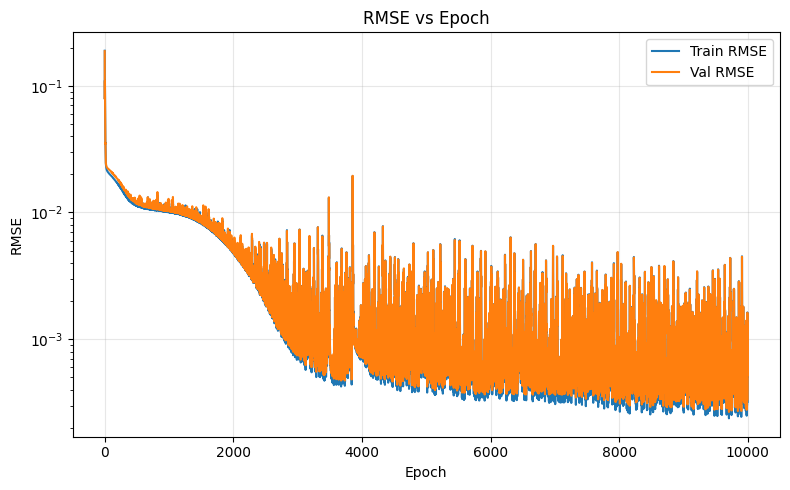

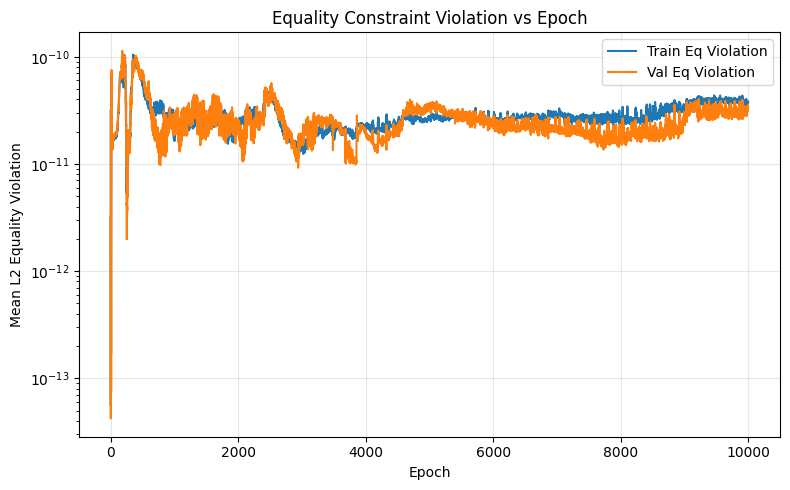

/tmp/ipykernel_1300/888418530.py:991: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


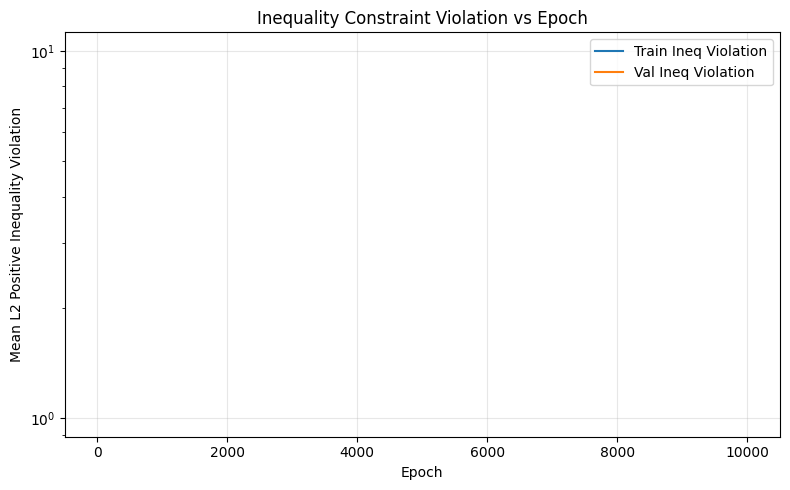


Saved results and trained model to:
/content/drive/MyDrive/Colab Notebooks/training_results_with_model_autograd.npz


In [ ]:
# ============================================================
# hard_projection_pooling_jax_auto_kkt_jitted.py
#
# Fully-jitted projection layer with automatic KKT generation.
#
# Key design choices:
#   - x is treated as a fixed parameter/data point, NOT as an optimization variable
#   - for each sample, projection solves only for z = (y, lambda, mu, s)
#   - constraints are built automatically from a JSON-like problem spec
#   - backward uses implicit differentiation, not AD through GN iterations
#   - functions are jitted where shape is fixed
#
# Problem solved per sample:
#
#   min_y 0.5 ||y - y_hat||^2
#   s.t.  ce(y, x) = 0
#         gi(y, x) <= 0
#
# Inequalities are converted to:
#   gi(y, x) + s = 0,  s >= 0
#
# Complementarity and nonnegativity are enforced with
# the smoothed Fischer-Burmeister function:
#   phi(mu_i, s_i) = sqrt(mu_i^2 + s_i^2 + eps^2) - mu_i - s_i = 0
#
# ============================================================

import math
from dataclasses import dataclass
from functools import partial
from typing import Callable, Dict, List, Tuple

import numpy as np
import pandas as pd

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from jax import random, lax
import optax

import matplotlib.pyplot as plt
import os

def sync(x):
    if hasattr(x, "block_until_ready"):
        x.block_until_ready()
    return x

# ============================================================
# Problem specification
# Replace only this block for a new problem of the same style
# ============================================================
# PROBLEM = {
#     "parameters": ["x1", "x2", "x3", "x4"],
#     "variables": ["y1", "y2", "y3", "y4", "y5"],
#     "constraints": [
#         "y2 + y3 - x1 - x2 == 0",
#         "x3 - y2 - y4 == 0",
#         "x4 - y3 - y5 == 0",
#         "y1*y2 + y1*y3 - 3*x1 - x2 == 0",
#         "y1*y2 + 2*y4 - 2.5*x3 <= 0",
#         "y1*y3 + 2*y5 - 1.5*x4 <= 0",
#     ],
#     "file_name": "/content/drive/MyDrive/Colab Notebooks/Pooling_dataset.csv",
# }

PROBLEM = {
  "parameters": ["x1", "x2", "x3"],
  "variables": ["y1", "y2", "y3", "y4", "y5","y6", "y7", "y8", "y9"],
  "binary_variables": [],
  "objective": "",
  "constraints": [
    "x1 + x2 - y1 - y2 == 0",
    "x1*0.697616946 - y1*y3 - y2*y6 == 0",
    "x1*0.302383054 - y1*y4 - y2*y7 == 0",
    "y3 + y4 + y5 - 1 == 0",
    "y6 + y7 + y8 - 1 == 0",
    "x3*y1 - y9 == 0"
  ],
  "file_name": "/content/drive/MyDrive/Colab Notebooks/ED_Col_Data.csv"
}

# ============================================================
# Hyperparameters
# ============================================================
FB_EPS = 1e-9

GN_MAX_ITERS = 50
GN_TOL = 1e-9
GN_REG = 1e-6

ARM_ALPHA = 1e-4
ARM_BETA = 0.5
ARM_MAX_STEPS = 20

LR = 1e-3
BATCH_SIZE = 240
EPOCHS = 10000
HIDDEN_SIZES = [64, 64]

DROP_LAST = False   # keeps batch shapes fixed -> avoids recompilation
PRINT_EVERY = 1000


# ============================================================
# Automatic expression parsing helpers
# ============================================================
def fb(a, b, eps):
    return jnp.sqrt(a * a + b * b + eps * eps) - a - b


def _safe_env():
    return {
        "jnp": jnp,
        "sin": jnp.sin,
        "cos": jnp.cos,
        "tan": jnp.tan,
        "exp": jnp.exp,
        "log": jnp.log,
        "sqrt": jnp.sqrt,
        "abs": jnp.abs,
        "maximum": jnp.maximum,
        "minimum": jnp.minimum,
        "pi": jnp.pi,
    }


def parse_constraint(constraint: str) -> Tuple[str, str]:
    """
    Converts:
        lhs == rhs  -> residual expr = lhs - rhs, type='eq'
        lhs <= rhs  -> residual expr = lhs - rhs, type='ineq'
        lhs >= rhs  -> residual expr = rhs - lhs, type='ineq'
    """
    c = constraint.strip()

    if "==" in c:
        left, right = c.split("==")
        return f"({left.strip()}) - ({right.strip()})", "eq"

    if "<=" in c:
        left, right = c.split("<=")
        return f"({left.strip()}) - ({right.strip()})", "ineq"

    if ">=" in c:
        left, right = c.split(">=")
        return f"({right.strip()}) - ({left.strip()})", "ineq"

    raise ValueError(f"Unsupported constraint format: {constraint}")


def make_scalar_expr_fn(
    expr: str,
    parameter_names: List[str],
    variable_names: List[str],
) -> Callable[[jnp.ndarray, jnp.ndarray], jnp.ndarray]:
    """
    Builds f(y, x) for a scalar residual expression.
    """
    env0 = _safe_env()

    def f(y, x):
        env = dict(env0)
        for i, name in enumerate(variable_names):
            env[name] = y[i]
        for i, name in enumerate(parameter_names):
            env[name] = x[i]
        return eval(expr, {"__builtins__": {}}, env)

    return f


# ============================================================
# Generic KKT problem container
# ============================================================
@dataclass
class ProjectionKKTProblem:
    parameter_names: List[str]
    variable_names: List[str]
    eq_exprs: List[str]
    ineq_exprs: List[str]
    eq_fns: List[Callable]
    ineq_fns: List[Callable]
    fb_eps: float = 1e-8

    @property
    def nx(self):
        return len(self.parameter_names)

    @property
    def ny(self):
        return len(self.variable_names)

    @property
    def ne(self):
        return len(self.eq_exprs)

    @property
    def ni(self):
        return len(self.ineq_exprs)

    @property
    def nz(self):
        # z = [y, lam, mu, s]
        return self.ny + self.ne + self.ni + self.ni

    def pack_z(self, y, lam, mu, s):
        return jnp.concatenate([y, lam, mu, s], axis=0)

    def unpack_z(self, z):
        ny, ne, ni = self.ny, self.ne, self.ni
        y = z[:ny]
        lam = z[ny:ny + ne]
        mu = z[ny + ne:ny + ne + ni]
        s = z[ny + ne + ni:ny + ne + 2 * ni]
        return y, lam, mu, s

    def ce(self, y, x):
        if self.ne == 0:
            return jnp.zeros((0,), dtype=y.dtype)
        return jnp.stack([f(y, x) for f in self.eq_fns], axis=0)

    def gi(self, y, x):
        if self.ni == 0:
            return jnp.zeros((0,), dtype=y.dtype)
        return jnp.stack([f(y, x) for f in self.ineq_fns], axis=0)

    def objective(self, y, y_hat):
        return 0.5 * jnp.dot(y - y_hat, y - y_hat)

    def lagrangian(self, y, lam, mu, s, x, y_hat):
        ce_val = self.ce(y, x)
        gi_val = self.gi(y, x)
        return (
            self.objective(y, y_hat)
            + jnp.dot(lam, ce_val)
            + jnp.dot(mu, gi_val + s)
        )

    def init_z(self, x, y_hat):
        y0 = y_hat
        lam0 = jnp.zeros((self.ne,), dtype=y_hat.dtype)
        mu0 = jnp.ones((self.ni,), dtype=y_hat.dtype) * 1e-2
        gi0 = self.gi(y0, x)
        s0 = jnp.maximum(-gi0, 1e-3) if self.ni > 0 else jnp.zeros((0,), dtype=y_hat.dtype)
        return self.pack_z(y0, lam0, mu0, s0)

    def print_summary(self):
        print("============================================================")
        print("Automatic KKT projection problem")
        print("Objective:")
        print("  min_y 0.5 ||y - y_hat||^2")
        print()

        print("Equalities ce(y,x)=0:")
        if self.ne == 0:
            print("  (none)")
        else:
            for i, e in enumerate(self.eq_exprs, start=1):
                print(f"  ce_{i}(y,x) = {e} = 0")
        print()

        print("Inequalities gi(y,x)<=0:")
        if self.ni == 0:
            print("  (none)")
        else:
            for i, e in enumerate(self.ineq_exprs, start=1):
                print(f"  gi_{i}(y,x) = {e} <= 0")
        print()

        print("Slack reformulation:")
        print("  gi(y,x) + s = 0,   s >= 0")
        print()

        print("KKT residual:")
        print("  R(z;x,y_hat) = [grad_y L; ce; gi+s; FB(mu,s)] = 0")
        print("  where z = (y, lambda, mu, s)")
        print("============================================================")


def build_projection_kkt_problem(problem_dict: Dict, fb_eps: float = 1e-8):
    parameter_names = problem_dict["parameters"]
    variable_names = problem_dict["variables"]
    constraints = problem_dict["constraints"]

    eq_exprs = []
    ineq_exprs = []

    for c in constraints:
        expr, sense = parse_constraint(c)
        if sense == "eq":
            eq_exprs.append(expr)
        elif sense == "ineq":
            ineq_exprs.append(expr)

    eq_fns = [
        make_scalar_expr_fn(expr, parameter_names, variable_names)
        for expr in eq_exprs
    ]
    ineq_fns = [
        make_scalar_expr_fn(expr, parameter_names, variable_names)
        for expr in ineq_exprs
    ]

    return ProjectionKKTProblem(
        parameter_names=parameter_names,
        variable_names=variable_names,
        eq_exprs=eq_exprs,
        ineq_exprs=ineq_exprs,
        eq_fns=eq_fns,
        ineq_fns=ineq_fns,
        fb_eps=fb_eps,
    )


# ============================================================
# Build problem once
# ============================================================
KKT = build_projection_kkt_problem(PROBLEM, fb_eps=FB_EPS)

NX = KKT.nx
NY = KKT.ny
NE = KKT.ne
NI = KKT.ni
NZ = KKT.nz


# ============================================================
# Jitted core functions
# x is a fixed parameter, not part of z
# ============================================================
def _ce(y, x):
    return KKT.ce(y, x)


def _gi(y, x):
    return KKT.gi(y, x)


def _lagrangian(y, lam, mu, s, x, y_hat):
    return KKT.lagrangian(y, lam, mu, s, x, y_hat)


def _kkt_residual(z, x, y_hat):
    y, lam, mu, s = KKT.unpack_z(z)

    ce_val = _ce(y, x)
    gi_val = _gi(y, x)

    grad_y_L = jax.grad(
        lambda yy: _lagrangian(yy, lam, mu, s, x, y_hat)
    )(y)

    primal_eq = ce_val
    primal_ineq = gi_val + s
    comp = fb(mu, s, KKT.fb_eps)

    return jnp.concatenate([grad_y_L, primal_eq, primal_ineq, comp], axis=0)


kkt_residual = jax.jit(_kkt_residual)
kkt_jac_z = jax.jit(jax.jacobian(_kkt_residual, argnums=0))
kkt_jac_yhat = jax.jit(jax.jacobian(_kkt_residual, argnums=2))


@jax.jit
def eq_constraints(y, x):
    return _ce(y, x)


@jax.jit
def ineq_constraints(y, x):
    return _gi(y, x)


@jax.jit
def merit(z, x, y_hat):
    r = kkt_residual(z, x, y_hat)
    return 0.5 * jnp.dot(r, r)


@jax.jit
def init_z(x, y_hat):
    return KKT.init_z(x, y_hat)


@jax.jit
def pack_z(y, lam, mu, s):
    return KKT.pack_z(y, lam, mu, s)


@jax.jit
def unpack_z(z):
    return KKT.unpack_z(z)


# ============================================================
# Gauss-Newton + Armijo
# ============================================================
@jax.jit
def gn_direction(z, x, y_hat):
    r = kkt_residual(z, x, y_hat)
    J = kkt_jac_z(z, x, y_hat)
    JTJ = J.T @ J + GN_REG * jnp.eye(NZ, dtype=z.dtype)
    rhs = -(J.T @ r)
    d = jnp.linalg.solve(JTJ, rhs)
    return d, r


@jax.jit
def armijo_line_search(z, d, x, y_hat):
    phi0 = merit(z, x, y_hat)
    r0 = kkt_residual(z, x, y_hat)
    J0 = kkt_jac_z(z, x, y_hat)
    grad_phi_dot_d = jnp.dot(J0.T @ r0, d)

    def body_fun(state, _):
        step, accepted = state
        z_trial = z + step * d
        phi_trial = merit(z_trial, x, y_hat)

        cond = phi_trial <= phi0 + ARM_ALPHA * step * grad_phi_dot_d
        new_step = jnp.where(accepted, step, jnp.where(cond, step, ARM_BETA * step))
        new_accepted = jnp.logical_or(accepted, cond)
        return (new_step, new_accepted), None

    (step, _), _ = lax.scan(
        body_fun,
        init=(jnp.array(1.0, dtype=z.dtype), jnp.array(False)),
        xs=None,
        length=ARM_MAX_STEPS,
    )
    return step

@jax.jit
def solve_kkt_gn_single(x, y_hat):
    z0 = init_z(x, y_hat)
    r0 = kkt_residual(z0, x, y_hat)
    res0 = jnp.linalg.norm(r0, ord=2)

    def cond_fun(state):
        k, z, res_norm = state
        return jnp.logical_and(k < GN_MAX_ITERS, res_norm > GN_TOL)

    def body_fun(state):
        k, z, _ = state
        d, _ = gn_direction(z, x, y_hat)
        step = armijo_line_search(z, d, x, y_hat)
        z_new = z + step * d
        r_new = kkt_residual(z_new, x, y_hat)
        res_new = jnp.linalg.norm(r_new, ord=2)
        return (k + 1, z_new, res_new)

    k_fin, z_fin, res_fin = lax.while_loop(cond_fun, body_fun, (0, z0, res0))
    return z_fin, k_fin, res_fin


# ============================================================
# Projection layer with implicit backward
# Since x is treated as fixed data, backward returns zero for x
# and only propagates gradient to y_hat.
# ============================================================
@jax.custom_vjp
def project_layer_single(x, y_hat):
    z_star, _, _ = solve_kkt_gn_single(x, y_hat)
    y_star, _, _, _ = KKT.unpack_z(z_star)
    return y_star


def project_layer_single_fwd(x, y_hat):
    z_star, iters, res_norm = solve_kkt_gn_single(x, y_hat)
    y_star, _, _, _ = KKT.unpack_z(z_star)
    return y_star, (z_star, x, y_hat, iters, res_norm)


def project_layer_single_bwd(res, g_y):
    z_star, x, y_hat, _, _ = res

    Jz = kkt_jac_z(z_star, x, y_hat)
    rhs = jnp.concatenate(
        [g_y, jnp.zeros((NE + NI + NI,), dtype=g_y.dtype)],
        axis=0,
    )

    reg = 1e-8 * jnp.eye(NZ, dtype=Jz.dtype)
    v = jnp.linalg.solve(Jz.T + reg, rhs)

    Jyhat = kkt_jac_yhat(z_star, x, y_hat)
    g_yhat = -(Jyhat.T @ v)

    # x is fixed data for the projection problem
    g_x = jnp.zeros_like(x)
    return (g_x, g_yhat)


project_layer_single.defvjp(project_layer_single_fwd, project_layer_single_bwd)

# # Autograd
# @jax.jit
# def solve_kkt_gn_single(x, y_hat):
#     z0 = init_z(x, y_hat)
#     r0 = kkt_residual(z0, x, y_hat)
#     res0 = jnp.linalg.norm(r0, ord=2)

#     def body_fun(state, _):
#         z, res_norm = state

#         d, _ = gn_direction(z, x, y_hat)
#         step = armijo_line_search(z, d, x, y_hat)
#         z_candidate = z + step * d

#         r_candidate = kkt_residual(z_candidate, x, y_hat)
#         res_candidate = jnp.linalg.norm(r_candidate, ord=2)

#         converged = res_norm <= GN_TOL

#         z_new = jnp.where(converged, z, z_candidate)
#         res_new = jnp.where(converged, res_norm, res_candidate)

#         return (z_new, res_new), None

#     (z_fin, res_fin), _ = lax.scan(
#         body_fun,
#         (z0, res0),
#         xs=None,
#         length=GN_MAX_ITERS,
#     )

#     return z_fin, jnp.array(GN_MAX_ITERS), res_fin

# def project_layer_single(x, y_hat):
#     z_star, _, _ = solve_kkt_gn_single(x, y_hat)
#     y_star, _, _, _ = KKT.unpack_z(z_star)
#     return y_star

project_layer = jax.jit(jax.vmap(project_layer_single, in_axes=(0, 0)))


# ============================================================
# Backbone MLP
# ============================================================
def glorot_init(key, in_dim, out_dim, dtype=jnp.float64):
    limit = math.sqrt(6.0 / (in_dim + out_dim))
    W = random.uniform(
        key,
        (in_dim, out_dim),
        minval=-limit,
        maxval=limit,
        dtype=dtype,
    )
    b = jnp.zeros((out_dim,), dtype=dtype)
    return {"W": W, "b": b}


def init_mlp_params(key, layer_sizes, dtype=jnp.float64):
    keys = random.split(key, len(layer_sizes) - 1)
    params = []
    for k, (din, dout) in zip(keys, zip(layer_sizes[:-1], layer_sizes[1:])):
        params.append(glorot_init(k, din, dout, dtype=dtype))
    return params


def mlp_apply(params, x):
    h = x
    for layer in params[:-1]:
        h = jax.nn.relu(h @ layer["W"] + layer["b"])
    return h @ params[-1]["W"] + params[-1]["b"]


batched_mlp_apply = jax.jit(jax.vmap(mlp_apply, in_axes=(None, 0)))


# ============================================================
# Model forward / losses
# ============================================================
@jax.jit
def model_forward(params, x_batch):
    y_hat = batched_mlp_apply(params, x_batch)
    y_proj = project_layer(x_batch, y_hat)
    return y_hat, y_proj


@jax.jit
def constraint_violation_batch(x_batch, y_batch):
    ce = jax.vmap(eq_constraints, in_axes=(0, 0))(y_batch, x_batch)
    gi = jax.vmap(ineq_constraints, in_axes=(0, 0))(y_batch, x_batch)

    eq_l2 = jnp.mean(jnp.linalg.norm(ce, axis=1))
    ineq_pos = jnp.maximum(gi, 0.0)
    ineq_l2 = jnp.mean(jnp.linalg.norm(ineq_pos, axis=1))
    return eq_l2, ineq_l2


@jax.jit
def loss_fn(params, x_batch, y_true_batch):
    _, y_proj = model_forward(params, x_batch)
    return jnp.mean(jnp.sum((y_proj - y_true_batch) ** 2, axis=1))


optimizer = optax.adam(LR)


@jax.jit
def train_step(params, opt_state, x_batch, y_batch):
    loss_val, grads = jax.value_and_grad(loss_fn)(params, x_batch, y_batch)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss_val


@jax.jit
def eval_metrics(params, x_batch, y_batch):
    y_hat, y_proj = model_forward(params, x_batch)
    loss = jnp.mean(jnp.sum((y_proj - y_batch) ** 2, axis=1))
    eq_l2, ineq_l2 = constraint_violation_batch(x_batch, y_proj)
    return loss, eq_l2, ineq_l2, y_hat, y_proj


# ============================================================
# Data utilities
# ============================================================
def load_dataset(csv_path, problem_dict, sample_size=None, dtype=np.float64, seed=42):
    df = pd.read_csv(csv_path)

    if sample_size is not None:
        df = df.sample(n=sample_size, random_state=seed)

    x_cols = problem_dict["parameters"]
    y_cols = problem_dict["variables"]

    X = df[x_cols].to_numpy(dtype=dtype)
    Y = df[y_cols].to_numpy(dtype=dtype)

    return X, Y


def train_val_split(X, Y, val_frac=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(X))
    rng.shuffle(idx)

    n_val = int(len(X) * val_frac)
    val_idx = idx[:n_val]
    tr_idx = idx[n_val:]

    return X[tr_idx], Y[tr_idx], X[val_idx], Y[val_idx]


def iterate_minibatches(X, Y, batch_size, seed=0, shuffle=True, drop_last=True):
    n = len(X)
    idx = np.arange(n)

    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(idx)

    last = (n // batch_size) * batch_size if drop_last else n
    for start in range(0, last, batch_size):
        end = start + batch_size
        if end > n and drop_last:
            break
        sel = idx[start:end]
        yield X[sel], Y[sel]


# ============================================================
# Diagnostics
# ============================================================
def print_problem_summary():
    print("\nProblem summary")
    print("------------------------------")
    print(f"parameters : {KKT.parameter_names}")
    print(f"variables  : {KKT.variable_names}")
    print(f"nx         : {NX}")
    print(f"ny         : {NY}")
    print(f"ne         : {NE}")
    print(f"ni         : {NI}")
    print(f"nz         : {NZ}")
    print("------------------------------\n")
    KKT.print_summary()


def print_sample_kkt_diagnostics(x, y_hat):
    z0 = init_z(x, y_hat)
    r0 = kkt_residual(z0, x, y_hat)
    J0 = kkt_jac_z(z0, x, y_hat)

    print("\nInitial sample KKT diagnostics")
    print("------------------------------")
    print("x shape     :", tuple(x.shape))
    print("y_hat shape :", tuple(y_hat.shape))
    print("z0 shape    :", tuple(z0.shape))
    print("R(z0) shape :", tuple(r0.shape))
    print("J(z0) shape :", tuple(J0.shape))
    print("||R(z0)||2  :", float(jnp.linalg.norm(r0)))
    print("------------------------------\n")


# ============================================================
# Main
# ============================================================
# def main():
#     import time
#     print_problem_summary()

#     X, Y = load_dataset(PROBLEM["file_name"], PROBLEM, sample_size = 4000, dtype=np.float64)
#     Xtr, Ytr, Xva, Yva = train_val_split(X, Y, val_frac=0.2, seed=42)

#     if DROP_LAST:
#         n_keep = (len(Xtr) // BATCH_SIZE) * BATCH_SIZE
#         Xtr = Xtr[:n_keep]
#         Ytr = Ytr[:n_keep]

#     Xtr = jnp.asarray(Xtr, dtype=jnp.float64)
#     Ytr = jnp.asarray(Ytr, dtype=jnp.float64)
#     Xva = jnp.asarray(Xva, dtype=jnp.float64)
#     Yva = jnp.asarray(Yva, dtype=jnp.float64)

#     key = random.PRNGKey(0)
#     layer_sizes = [NX] + HIDDEN_SIZES + [NY]
#     params = init_mlp_params(key, layer_sizes, dtype=jnp.float64)
#     opt_state = optimizer.init(params)

#     yhat0 = batched_mlp_apply(params, Xtr[:1])[0]
#     print_sample_kkt_diagnostics(Xtr[0], yhat0)

#     print("Starting training...")
#     print(f"Train size: {Xtr.shape[0]}, Val size: {Xva.shape[0]}")

#     t0 = time.time()
#     for epoch in range(1, EPOCHS + 1):
#         t0_epoch = time.time()
#         for xb, yb in iterate_minibatches(
#             np.array(Xtr),
#             np.array(Ytr),
#             batch_size=BATCH_SIZE,
#             seed=epoch,
#             shuffle=True,
#             drop_last=DROP_LAST,
#         ):
#             xb = jnp.asarray(xb, dtype=jnp.float64)
#             yb = jnp.asarray(yb, dtype=jnp.float64)

#             params, opt_state, loss_val = train_step(params, opt_state, xb, yb)
#         tf_epoch = time.time()
#         tr_loss, tr_eq, tr_ineq, _, _ = eval_metrics(params, Xtr, Ytr)
#         va_loss, va_eq, va_ineq, _, _ = eval_metrics(params, Xva, Yva)

#         if epoch == 1 or epoch % 10 == 0:
#             print(
#                 f"Epoch {epoch:4d} | "
#                 f"train_loss={float(tr_loss):.6e} | "
#                 f"val_loss={float(va_loss):.6e} | "
#                 f"train_eq={float(tr_eq):.3e} | "
#                 f"train_ineq={float(tr_ineq):.3e} | "
#                 f"val_eq={float(va_eq):.3e} | "
#                 f"val_ineq={float(va_ineq):.3e}"
#                 f" | time (epoch no: {epoch})={tf_epoch - t0_epoch:.2f}s"
#             )
#     tf = time.time()
#     print(f"Training time: {tf - t0:.2f} seconds")

#     va_loss, va_eq, va_ineq, yhat_va, yproj_va = eval_metrics(params, Xva, Yva)

#     print("\nFinal validation metrics:")
#     print(f"  loss      = {float(va_loss):.6e}")
#     print(f"  eq viol   = {float(va_eq):.6e}")
#     print(f"  ineq viol = {float(va_ineq):.6e}")

#     i = 0
#     print("\nExample validation sample:")
#     print("x       =", np.array(Xva[i]))
#     print("y_true  =", np.array(Yva[i]))
#     print("y_hat   =", np.array(yhat_va[i]))
#     print("y_proj  =", np.array(yproj_va[i]))

#     ce_i = np.array(eq_constraints(yproj_va[i], Xva[i]))
#     gi_i = np.array(ineq_constraints(yproj_va[i], Xva[i]))
#     print("eq(y)   =", ce_i)
#     print("ineq(y) =", gi_i, "  (should be <= 0)")

#     z_star, iters, res_norm = solve_kkt_gn_single(Xva[i], yhat_va[i])
#     y_star, lam_star, mu_star, s_star = KKT.unpack_z(z_star)

#     print("\nSample projection solve info:")
#     print("iters         =", int(iters))
#     print("residual_norm =", float(res_norm))
#     print("y_star        =", np.array(y_star))
#     print("lambda        =", np.array(lam_star))
#     print("mu            =", np.array(mu_star))
#     print("slack         =", np.array(s_star))

def main():
    import time

    print_problem_summary()

    X, Y = load_dataset(PROBLEM["file_name"], PROBLEM, sample_size=1200, dtype=np.float64)
    Xtr, Ytr, Xva, Yva = train_val_split(X, Y, val_frac=0.2, seed=42)

    if DROP_LAST:
        n_keep = (len(Xtr) // BATCH_SIZE) * BATCH_SIZE
        Xtr = Xtr[:n_keep]
        Ytr = Ytr[:n_keep]

    Xtr = jnp.asarray(Xtr, dtype=jnp.float64)
    Ytr = jnp.asarray(Ytr, dtype=jnp.float64)
    Xva = jnp.asarray(Xva, dtype=jnp.float64)
    Yva = jnp.asarray(Yva, dtype=jnp.float64)

    key = random.PRNGKey(0)
    layer_sizes = [NX] + HIDDEN_SIZES + [NY]
    params = init_mlp_params(key, layer_sizes, dtype=jnp.float64)
    opt_state = optimizer.init(params)

    yhat0 = batched_mlp_apply(params, Xtr[:1])[0]
    print_sample_kkt_diagnostics(Xtr[0], yhat0)

    print("Starting training...")
    print(f"Train size: {Xtr.shape[0]}, Val size: {Xva.shape[0]}")

    epoch_hist = []
    train_rmse_hist = []
    val_rmse_hist = []
    train_eq_hist = []
    val_eq_hist = []
    train_ineq_hist = []
    val_ineq_hist = []

    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        t0_epoch = time.time()

        t_batch_total = 0.0
        t_to_device = 0.0
        t_train_step = 0.0
        nbatches = 0

        for xb, yb in iterate_minibatches(
            np.array(Xtr),
            np.array(Ytr),
            batch_size=BATCH_SIZE,
            seed=epoch,
            shuffle=True,
            drop_last=DROP_LAST,
        ):
            t0_batch = time.time()

            t1 = time.time()
            xb = jnp.asarray(xb, dtype=jnp.float64)
            yb = jnp.asarray(yb, dtype=jnp.float64)
            sync(xb)
            sync(yb)
            t2 = time.time()

            t3 = time.time()
            params, opt_state, loss_val = train_step(params, opt_state, xb, yb)
            sync(loss_val)   # forces train_step to actually finish
            t4 = time.time()

            t_to_device += (t2 - t1)
            t_train_step += (t4 - t3)
            t_batch_total += (time.time() - t0_batch)
            nbatches += 1

        tf_epoch = time.time()

        t5 = time.time()
        tr_loss, tr_eq, tr_ineq, _, _ = eval_metrics(params, Xtr, Ytr)
        sync(tr_loss)
        sync(tr_eq)
        sync(tr_ineq)
        t6 = time.time()

        va_loss, va_eq, va_ineq, _, _ = eval_metrics(params, Xva, Yva)
        sync(va_loss)
        sync(va_eq)
        sync(va_ineq)
        t7 = time.time()

        tr_rmse = jnp.sqrt(tr_loss / NY)
        va_rmse = jnp.sqrt(va_loss / NY)
        sync(tr_rmse)
        sync(va_rmse)

        epoch_hist.append(epoch)
        train_rmse_hist.append(float(tr_rmse))
        val_rmse_hist.append(float(va_rmse))
        train_eq_hist.append(float(tr_eq))
        val_eq_hist.append(float(va_eq))
        train_ineq_hist.append(float(tr_ineq))
        val_ineq_hist.append(float(va_ineq))

        if epoch == 1 or epoch % PRINT_EVERY == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train_loss={float(tr_loss):.6e} | "
                f"val_loss={float(va_loss):.6e} | "
                f"train_rmse={float(tr_rmse):.6e} | "
                f"val_rmse={float(va_rmse):.6e} | "
                f"train_eq={float(tr_eq):.3e} | "
                f"train_ineq={float(tr_ineq):.3e} | "
                f"val_eq={float(va_eq):.3e} | "
                f"val_ineq={float(va_ineq):.3e} | "
                f"to_device={t_to_device:.4f}s | "
                f"train_step={t_train_step:.4f}s | "
                f"train_loop={tf_epoch - t0_epoch:.4f}s | "
                f"train_eval={t6 - t5:.4f}s | "
                f"val_eval={t7 - t6:.4f}s | "
                f"epoch_total={t7 - t0_epoch:.4f}s | "
                f"avg_batch={(t_batch_total / nbatches):.4f}s"
            )

    tf = time.time()
    print(f"Training time: {tf - t0:.2f} seconds")

    va_loss, va_eq, va_ineq, yhat_va, yproj_va = eval_metrics(params, Xva, Yva)
    va_rmse = jnp.sqrt(va_loss / NY)

    print("\nFinal validation metrics:")
    print(f"  loss      = {float(va_loss):.6e}")
    print(f"  rmse      = {float(va_rmse):.6e}")
    print(f"  eq viol   = {float(va_eq):.6e}")
    print(f"  ineq viol = {float(va_ineq):.6e}")

    i = 0
    print("\nExample validation sample:")
    print("x       =", np.array(Xva[i]))
    print("y_true  =", np.array(Yva[i]))
    print("y_hat   =", np.array(yhat_va[i]))
    print("y_proj  =", np.array(yproj_va[i]))

    ce_i = np.array(eq_constraints(yproj_va[i], Xva[i]))
    gi_i = np.array(ineq_constraints(yproj_va[i], Xva[i]))
    print("eq(y)   =", ce_i)
    print("ineq(y) =", gi_i, "  (should be <= 0)")

    z_star, iters, res_norm = solve_kkt_gn_single(Xva[i], yhat_va[i])
    y_star, lam_star, mu_star, s_star = KKT.unpack_z(z_star)

    print("\nSample projection solve info:")
    print("iters         =", int(iters))
    print("residual_norm =", float(res_norm))
    print("y_star        =", np.array(y_star))
    print("lambda        =", np.array(lam_star))
    print("mu            =", np.array(mu_star))
    print("slack         =", np.array(s_star))

    # ------------------------------------------------------------
    # Plot 1: RMSE vs Epoch
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epoch_hist, train_rmse_hist, label="Train RMSE")
    plt.plot(epoch_hist, val_rmse_hist, label="Val RMSE")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.title("RMSE vs Epoch")
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot 2: Equality constraint violation vs Epoch
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epoch_hist, train_eq_hist, label="Train Eq Violation")
    plt.plot(epoch_hist, val_eq_hist, label="Val Eq Violation")
    plt.xlabel("Epoch")
    plt.ylabel("Mean L2 Equality Violation")
    plt.title("Equality Constraint Violation vs Epoch")
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot 3: Inequality constraint violation vs Epoch
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epoch_hist, train_ineq_hist, label="Train Ineq Violation")
    plt.plot(epoch_hist, val_ineq_hist, label="Val Ineq Violation")
    plt.xlabel("Epoch")
    plt.ylabel("Mean L2 Positive Inequality Violation")
    plt.title("Inequality Constraint Violation vs Epoch")
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Save results + trained network parameters
    # ------------------------------------------------------------
    save_dir = "/content/drive/MyDrive/Colab Notebooks"
    os.makedirs(save_dir, exist_ok=True)

    save_path = os.path.join(save_dir, "training_results_with_model_autograd.npz")

    # extract weights and biases
    weights = [np.array(layer["W"]) for layer in params]
    biases  = [np.array(layer["b"]) for layer in params]

    np.savez(
        save_path,

        # training history
        epoch=np.array(epoch_hist),
        train_rmse=np.array(train_rmse_hist),
        val_rmse=np.array(val_rmse_hist),
        train_eq=np.array(train_eq_hist),
        val_eq=np.array(val_eq_hist),
        train_ineq=np.array(train_ineq_hist),
        val_ineq=np.array(val_ineq_hist),

        # validation predictions
        Xva=np.array(Xva),
        Yva=np.array(Yva),
        yhat_va=np.array(yhat_va),
        yproj_va=np.array(yproj_va),

        # trained network parameters
        weights=np.array(weights, dtype=object),
        biases=np.array(biases, dtype=object),

        # metadata
        layer_sizes=np.array([NX] + HIDDEN_SIZES + [NY]),
        NX=np.array([NX]),
        NY=np.array([NY]),
        NE=np.array([NE]),
        NI=np.array([NI]),
        NZ=np.array([NZ]),
        epochs_total=np.array([EPOCHS]),
        batch_size=np.array([BATCH_SIZE]),
        learning_rate=np.array([LR])
    )

    print(f"\nSaved results and trained model to:\n{save_path}")


if __name__ == "__main__":
    main()

In [ ]:
!pip install utils

  Preparing metadata (setup.py) ... done
  Created wheel for utils: filename=utils-1.0.2-py2.py3-none-any.whl size=13906 sha256=3a1aeecdc494aa64337f9044c9245d6f5d2143684e7259a8b4b4043b50644463
  Stored in directory: /root/.cache/pip/wheels/b6/a1/81/1036477786ae0e17b522f6f5a838f9bc4288d1016fc5d0e1ec
Successfully built utils


In [ ]:
# ============================================================
# hard_projection_pooling_jax_symbolic_kkt_jitted.py
#
# Symbolic KKT projection layer:
#   - constraints parsed from strings
#   - KKT residual built symbolically with SymPy
#   - Jacobian wrt z = [y, lambda, mu, s] built symbolically once
#   - Jacobian wrt y_hat built symbolically once
#   - numerical evaluators generated once with sympy.lambdify using JAX ops
#   - runtime uses jitted residual/Jacobian evaluators
#
# Problem solved per sample:
#
#   min_y 0.5 ||y - y_hat||^2
#   s.t.  ce(y, x) = 0
#         gi(y, x) <= 0
#
# Inequalities are converted to:
#   gi(y, x) + s = 0,  s >= 0
#
# Complementarity is enforced with smoothed Fischer-Burmeister:
#   phi(mu_i, s_i) = sqrt(mu_i^2 + s_i^2 + eps^2) - mu_i - s_i = 0
# ============================================================

import math
from dataclasses import dataclass
from typing import Callable, Dict, List, Tuple

import numpy as np
import pandas as pd
import sympy as sp

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from jax import random, lax
import optax


# ============================================================
# Problem specification
# ============================================================
PROBLEM = {
    "parameters": [f"x{i}" for i in range(1, 11)],
    "variables": [f"y{i}" for i in range(1, 51)],
    "binary_variables": [],
    "objective": "",
    "constraints": [
        # --------------------------------------------------
        # 20 equalities
        # --------------------------------------------------
        "x1  - y1  - y11 == 0",
        "x2  - y2  - y12 == 0",
        "x3  - y3  - y13 == 0",
        "x4  - y4  - y14 == 0",
        "x5  - y5  - y15 == 0",
        "x6  - y6  - y16 == 0",
        "x7  - y7  - y17 == 0",
        "x8  - y8  - y18 == 0",
        "x9  - y9  - y19 == 0",
        "x10 - y10 - y20 == 0",

        "y21 - (0.30*y1  + 0.70*y11 + 0.10*x2 ) == 0",
        "y22 - (0.30*y2  + 0.70*y12 + 0.10*x3 ) == 0",
        "y23 - (0.30*y3  + 0.70*y13 + 0.10*x4 ) == 0",
        "y24 - (0.30*y4  + 0.70*y14 + 0.10*x5 ) == 0",
        "y25 - (0.30*y5  + 0.70*y15 + 0.10*x6 ) == 0",
        "y26 - (0.30*y6  + 0.70*y16 + 0.10*x7 ) == 0",
        "y27 - (0.30*y7  + 0.70*y17 + 0.10*x8 ) == 0",
        "y28 - (0.30*y8  + 0.70*y18 + 0.10*x9 ) == 0",
        "y29 - (0.30*y9  + 0.70*y19 + 0.10*x10) == 0",
        "y30 - (0.30*y10 + 0.70*y20 + 0.10*x1 ) == 0",

        # --------------------------------------------------
        # 20 inequalities
        # --------------------------------------------------
        "y31 - (0.20 + y1**2  + 0.10*y21**2) <= 0",
        "y32 - (0.20 + y2**2  + 0.10*y22**2) <= 0",
        "y33 - (0.20 + y3**2  + 0.10*y23**2) <= 0",
        "y34 - (0.20 + y4**2  + 0.10*y24**2) <= 0",
        "y35 - (0.20 + y5**2  + 0.10*y25**2) <= 0",
        "y36 - (0.20 + y6**2  + 0.10*y26**2) <= 0",
        "y37 - (0.20 + y7**2  + 0.10*y27**2) <= 0",
        "y38 - (0.20 + y8**2  + 0.10*y28**2) <= 0",
        "y39 - (0.20 + y9**2  + 0.10*y29**2) <= 0",
        "y40 - (0.20 + y10**2 + 0.10*y30**2) <= 0",

        "y41 + y11 + 0.50*y21 - (4.00 + 0.20*x1 ) <= 0",
        "y42 + y12 + 0.50*y22 - (4.00 + 0.20*x2 ) <= 0",
        "y43 + y13 + 0.50*y23 - (4.00 + 0.20*x3 ) <= 0",
        "y44 + y14 + 0.50*y24 - (4.00 + 0.20*x4 ) <= 0",
        "y45 + y15 + 0.50*y25 - (4.00 + 0.20*x5 ) <= 0",
        "y46 + y16 + 0.50*y26 - (4.00 + 0.20*x6 ) <= 0",
        "y47 + y17 + 0.50*y27 - (4.00 + 0.20*x7 ) <= 0",
        "y48 + y18 + 0.50*y28 - (4.00 + 0.20*x8 ) <= 0",
        "y49 + y19 + 0.50*y29 - (4.00 + 0.20*x9 ) <= 0",
        "y50 + y20 + 0.50*y30 - (4.00 + 0.20*x10) <= 0",
    ],
    "file_name": "synthetic_10x50_eq20_ineq20.csv",
}


# ============================================================
# Synthetic dataset generator
# ============================================================
def generate_synthetic_dataset(
    csv_path="synthetic_10x50_eq20_ineq20.csv",
    n_samples=4000,
    seed=123,
):
    rng = np.random.default_rng(seed)

    rows = []
    for _ in range(n_samples):
        x = rng.uniform(0.5, 2.0, size=10)
        y = np.zeros(50, dtype=np.float64)

        alpha = rng.uniform(0.20, 0.80, size=10)
        y[0:10] = alpha * x
        y[10:20] = (1.0 - alpha) * x

        y[20] = 0.30 * y[0] + 0.70 * y[10] + 0.10 * x[1]
        y[21] = 0.30 * y[1] + 0.70 * y[11] + 0.10 * x[2]
        y[22] = 0.30 * y[2] + 0.70 * y[12] + 0.10 * x[3]
        y[23] = 0.30 * y[3] + 0.70 * y[13] + 0.10 * x[4]
        y[24] = 0.30 * y[4] + 0.70 * y[14] + 0.10 * x[5]
        y[25] = 0.30 * y[5] + 0.70 * y[15] + 0.10 * x[6]
        y[26] = 0.30 * y[6] + 0.70 * y[16] + 0.10 * x[7]
        y[27] = 0.30 * y[7] + 0.70 * y[17] + 0.10 * x[8]
        y[28] = 0.30 * y[8] + 0.70 * y[18] + 0.10 * x[9]
        y[29] = 0.30 * y[9] + 0.70 * y[19] + 0.10 * x[0]

        ub31_40 = np.zeros(10, dtype=np.float64)
        for i in range(10):
            ub31_40[i] = 0.20 + y[i] ** 2 + 0.10 * y[20 + i] ** 2
        beta1 = rng.uniform(0.20, 0.70, size=10)
        y[30:40] = beta1 * ub31_40

        ub41_50 = np.zeros(10, dtype=np.float64)
        for i in range(10):
            ub41_50[i] = 4.00 + 0.20 * x[i] - y[10 + i] - 0.50 * y[20 + i]
        beta2 = rng.uniform(0.20, 0.70, size=10)
        y[40:50] = beta2 * np.maximum(ub41_50, 1e-6)

        row = {}
        for i in range(10):
            row[f"x{i+1}"] = x[i]
        for i in range(50):
            row[f"y{i+1}"] = y[i]
        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(csv_path, index=False)
    print(f"Saved dataset to: {csv_path}")


# ============================================================
# Hyperparameters
# ============================================================
FB_EPS = 1e-9

GN_MAX_ITERS = 20
GN_TOL = 1e-9
GN_REG = 1e-6

ARM_ALPHA = 0.5
ARM_BETA = 0.5
ARM_MAX_STEPS = 10

LR = 1e-3
BATCH_SIZE = 800
EPOCHS = 30
HIDDEN_SIZES = [128, 128]

DROP_LAST = False


# ============================================================
# Parsing helpers
# ============================================================
def fb(a, b, eps):
    return jnp.sqrt(a * a + b * b + eps * eps) - a - b


def parse_constraint(constraint: str) -> Tuple[str, str]:
    """
    Converts:
        lhs == rhs  -> residual expr = lhs - rhs, type='eq'
        lhs <= rhs  -> residual expr = lhs - rhs, type='ineq'
        lhs >= rhs  -> residual expr = rhs - lhs, type='ineq'
    """
    c = constraint.strip()

    if "==" in c:
        left, right = c.split("==")
        return f"({left.strip()}) - ({right.strip()})", "eq"

    if "<=" in c:
        left, right = c.split("<=")
        return f"({left.strip()}) - ({right.strip()})", "ineq"

    if ">=" in c:
        left, right = c.split(">=")
        return f"({right.strip()}) - ({left.strip()})", "ineq"

    raise ValueError(f"Unsupported constraint format: {constraint}")


# ============================================================
# Symbolic-to-JAX codegen
# ============================================================
JAX_LAMBDIFY_MODULES = [
    {
        "sin": jnp.sin,
        "cos": jnp.cos,
        "tan": jnp.tan,
        "exp": jnp.exp,
        "log": jnp.log,
        "sqrt": jnp.sqrt,
        "Abs": jnp.abs,
        "abs": jnp.abs,
        "sign": jnp.sign,
        "maximum": jnp.maximum,
        "minimum": jnp.minimum,
    }
]


def _flatten_sympy_output(sym_expr):
    if isinstance(sym_expr, sp.MatrixBase):
        return list(sym_expr)
    if isinstance(sym_expr, (list, tuple)):
        flat = []
        for item in sym_expr:
            if isinstance(item, sp.MatrixBase):
                flat.extend(list(item))
            else:
                flat.append(item)
        return flat
    return [sym_expr]


def _build_jax_matrix_eval(sym_expr, arg_syms, out_shape, simplify=False):
    expr = sp.simplify(sym_expr) if simplify else sym_expr
    flat_expr = _flatten_sympy_output(expr)

    fn = sp.lambdify(arg_syms, flat_expr, modules=JAX_LAMBDIFY_MODULES)

    def wrapped(*vals):
        out = fn(*vals)
        return jnp.asarray(out, dtype=jnp.float64).reshape(out_shape)

    return wrapped


# ============================================================
# Generic KKT problem container
# ============================================================
@dataclass
class ProjectionKKTProblem:
    parameter_names: List[str]
    variable_names: List[str]
    eq_exprs: List[str]
    ineq_exprs: List[str]
    fb_eps: float
    ce_fn_flat: Callable
    gi_fn_flat: Callable
    residual_fn_flat: Callable
    jac_z_fn_flat: Callable
    jac_yhat_fn_flat: Callable

    @property
    def nx(self):
        return len(self.parameter_names)

    @property
    def ny(self):
        return len(self.variable_names)

    @property
    def ne(self):
        return len(self.eq_exprs)

    @property
    def ni(self):
        return len(self.ineq_exprs)

    @property
    def nz(self):
        return self.ny + self.ne + self.ni + self.ni

    def pack_z(self, y, lam, mu, s):
        return jnp.concatenate([y, lam, mu, s], axis=0)

    def unpack_z(self, z):
        ny, ne, ni = self.ny, self.ne, self.ni
        y = z[:ny]
        lam = z[ny:ny + ne]
        mu = z[ny + ne:ny + ne + ni]
        s = z[ny + ne + ni:ny + ne + 2 * ni]
        return y, lam, mu, s

    def ce(self, y, x):
        if self.ne == 0:
            return jnp.zeros((0,), dtype=y.dtype)
        args = tuple(y[i] for i in range(self.ny)) + tuple(x[i] for i in range(self.nx))
        return self.ce_fn_flat(*args).reshape((self.ne,)).astype(y.dtype)

    def gi(self, y, x):
        if self.ni == 0:
            return jnp.zeros((0,), dtype=y.dtype)
        args = tuple(y[i] for i in range(self.ny)) + tuple(x[i] for i in range(self.nx))
        return self.gi_fn_flat(*args).reshape((self.ni,)).astype(y.dtype)

    def residual(self, z, x, y_hat):
        args = (
            tuple(z[i] for i in range(self.nz))
            + tuple(x[i] for i in range(self.nx))
            + tuple(y_hat[i] for i in range(self.ny))
            + (self.fb_eps,)
        )
        return self.residual_fn_flat(*args).reshape((self.nz,)).astype(z.dtype)

    def jac_z(self, z, x, y_hat):
        args = (
            tuple(z[i] for i in range(self.nz))
            + tuple(x[i] for i in range(self.nx))
            + tuple(y_hat[i] for i in range(self.ny))
            + (self.fb_eps,)
        )
        return self.jac_z_fn_flat(*args).reshape((self.nz, self.nz)).astype(z.dtype)

    def jac_yhat(self, z, x, y_hat):
        args = (
            tuple(z[i] for i in range(self.nz))
            + tuple(x[i] for i in range(self.nx))
            + tuple(y_hat[i] for i in range(self.ny))
            + (self.fb_eps,)
        )
        return self.jac_yhat_fn_flat(*args).reshape((self.nz, self.ny)).astype(z.dtype)

    def init_z(self, x, y_hat):
        y0 = y_hat
        lam0 = jnp.zeros((self.ne,), dtype=y_hat.dtype)
        mu0 = jnp.ones((self.ni,), dtype=y_hat.dtype) * 1e-2
        gi0 = self.gi(y0, x)
        s0 = jnp.maximum(-gi0, 1e-3) if self.ni > 0 else jnp.zeros((0,), dtype=y_hat.dtype)
        return self.pack_z(y0, lam0, mu0, s0)

    def print_summary(self):
        print("============================================================")
        print("Automatic symbolic KKT projection problem")
        print("Objective:")
        print("  min_y 0.5 ||y - y_hat||^2")
        print()

        print("Equalities ce(y,x)=0:")
        if self.ne == 0:
            print("  (none)")
        else:
            for i, e in enumerate(self.eq_exprs, start=1):
                print(f"  ce_{i}(y,x) = {e} = 0")
        print()

        print("Inequalities gi(y,x)<=0:")
        if self.ni == 0:
            print("  (none)")
        else:
            for i, e in enumerate(self.ineq_exprs, start=1):
                print(f"  gi_{i}(y,x) = {e} <= 0")
        print()

        print("Slack reformulation:")
        print("  gi(y,x) + s = 0,   s >= 0")
        print()

        print("KKT residual:")
        print("  R(z;x,y_hat) = [grad_y L; ce; gi+s; FB(mu,s)] = 0")
        print("  where z = (y, lambda, mu, s)")
        print("============================================================")


def build_projection_kkt_problem_symbolic(problem_dict: Dict, fb_eps: float = 1e-8):
    parameter_names = problem_dict["parameters"]
    variable_names = problem_dict["variables"]
    constraints = problem_dict["constraints"]

    nx = len(parameter_names)
    ny = len(variable_names)

    # Symbolic scalar variables
    x_syms = [sp.Symbol(name, real=True) for name in parameter_names]
    y_syms = [sp.Symbol(name, real=True) for name in variable_names]

    eq_exprs_str = []
    ineq_exprs_str = []

    for c in constraints:
        expr, sense = parse_constraint(c)
        if sense == "eq":
            eq_exprs_str.append(expr)
        else:
            ineq_exprs_str.append(expr)

    ne = len(eq_exprs_str)
    ni = len(ineq_exprs_str)

    lam_syms = [sp.Symbol(f"lam{i+1}", real=True) for i in range(ne)]
    mu_syms = [sp.Symbol(f"mu{i+1}", real=True) for i in range(ni)]
    s_syms = [sp.Symbol(f"s{i+1}", real=True) for i in range(ni)]
    yhat_syms = [sp.Symbol(f"yhat{i+1}", real=True) for i in range(ny)]
    fb_eps_sym = sp.Symbol("fb_eps", positive=True, real=True)

    sym_env = {s.name: s for s in x_syms + y_syms + lam_syms + mu_syms + s_syms + yhat_syms}
    sym_env.update({
        "sin": sp.sin,
        "cos": sp.cos,
        "tan": sp.tan,
        "exp": sp.exp,
        "log": sp.log,
        "sqrt": sp.sqrt,
        "abs": sp.Abs,
        "Abs": sp.Abs,
        "pi": sp.pi,
    })

    ce_list = [sp.sympify(expr, locals=sym_env) for expr in eq_exprs_str]
    gi_list = [sp.sympify(expr, locals=sym_env) for expr in ineq_exprs_str]

    ce_vec = sp.Matrix(ce_list) if ne > 0 else sp.Matrix.zeros(0, 1)
    gi_vec = sp.Matrix(gi_list) if ni > 0 else sp.Matrix.zeros(0, 1)

    y_vec = sp.Matrix(y_syms)
    yhat_vec = sp.Matrix(yhat_syms)
    lam_vec = sp.Matrix(lam_syms) if ne > 0 else sp.Matrix.zeros(0, 1)
    mu_vec = sp.Matrix(mu_syms) if ni > 0 else sp.Matrix.zeros(0, 1)
    s_vec = sp.Matrix(s_syms) if ni > 0 else sp.Matrix.zeros(0, 1)

    objective = sp.Rational(1, 2) * sum((y_syms[i] - yhat_syms[i]) ** 2 for i in range(ny))
    lag_eq = (lam_vec.T * ce_vec)[0] if ne > 0 else sp.Integer(0)
    lag_ineq = (mu_vec.T * (gi_vec + s_vec))[0] if ni > 0 else sp.Integer(0)
    L = objective + lag_eq + lag_ineq

    grad_y_L = sp.Matrix([sp.diff(L, yi) for yi in y_syms])

    primal_eq = ce_vec
    primal_ineq = gi_vec + s_vec if ni > 0 else sp.Matrix.zeros(0, 1)
    comp = (
        sp.Matrix([
            sp.sqrt(mu_syms[i] ** 2 + s_syms[i] ** 2 + fb_eps_sym ** 2) - mu_syms[i] - s_syms[i]
            for i in range(ni)
        ])
        if ni > 0 else sp.Matrix.zeros(0, 1)
    )

    residual_vec = sp.Matrix.vstack(grad_y_L, primal_eq, primal_ineq, comp)

    z_syms = y_syms + lam_syms + mu_syms + s_syms
    jac_z = residual_vec.jacobian(z_syms)
    jac_yhat = residual_vec.jacobian(yhat_syms)

    ce_args = y_syms + x_syms
    full_args = z_syms + x_syms + yhat_syms + [fb_eps_sym]

    ce_fn_flat = _build_jax_matrix_eval(ce_vec, ce_args, (ne,), simplify=False) if ne > 0 else None
    gi_fn_flat = _build_jax_matrix_eval(gi_vec, ce_args, (ni,), simplify=False) if ni > 0 else None
    residual_fn_flat = _build_jax_matrix_eval(residual_vec, full_args, (ny + ne + ni + ni,), simplify=False)
    jac_z_fn_flat = _build_jax_matrix_eval(jac_z, full_args, (ny + ne + ni + ni, ny + ne + ni + ni), simplify=False)
    jac_yhat_fn_flat = _build_jax_matrix_eval(jac_yhat, full_args, (ny + ne + ni + ni, ny), simplify=False)

    return ProjectionKKTProblem(
        parameter_names=parameter_names,
        variable_names=variable_names,
        eq_exprs=eq_exprs_str,
        ineq_exprs=ineq_exprs_str,
        fb_eps=fb_eps,
        ce_fn_flat=ce_fn_flat,
        gi_fn_flat=gi_fn_flat,
        residual_fn_flat=residual_fn_flat,
        jac_z_fn_flat=jac_z_fn_flat,
        jac_yhat_fn_flat=jac_yhat_fn_flat,
    )


# ============================================================
# Build problem once
# ============================================================
KKT = build_projection_kkt_problem_symbolic(PROBLEM, fb_eps=FB_EPS)

NX = KKT.nx
NY = KKT.ny
NE = KKT.ne
NI = KKT.ni
NZ = KKT.nz


# ============================================================
# Jitted core functions
# ============================================================
def _ce(y, x):
    return KKT.ce(y, x)


def _gi(y, x):
    return KKT.gi(y, x)


def _kkt_residual(z, x, y_hat):
    return KKT.residual(z, x, y_hat)


def _kkt_jac_z(z, x, y_hat):
    return KKT.jac_z(z, x, y_hat)


def _kkt_jac_yhat(z, x, y_hat):
    return KKT.jac_yhat(z, x, y_hat)


kkt_residual = jax.jit(_kkt_residual)
kkt_jac_z = jax.jit(_kkt_jac_z)
kkt_jac_yhat = jax.jit(_kkt_jac_yhat)


@jax.jit
def eq_constraints(y, x):
    return _ce(y, x)


@jax.jit
def ineq_constraints(y, x):
    return _gi(y, x)


@jax.jit
def merit(z, x, y_hat):
    r = kkt_residual(z, x, y_hat)
    return 0.5 * jnp.dot(r, r)


@jax.jit
def init_z(x, y_hat):
    return KKT.init_z(x, y_hat)


@jax.jit
def pack_z(y, lam, mu, s):
    return KKT.pack_z(y, lam, mu, s)


@jax.jit
def unpack_z(z):
    return KKT.unpack_z(z)


# ============================================================
# Gauss-Newton + Armijo
# ============================================================
@jax.jit
def gn_direction(z, x, y_hat):
    r = kkt_residual(z, x, y_hat)
    J = kkt_jac_z(z, x, y_hat)
    JTJ = J.T @ J + GN_REG * jnp.eye(NZ, dtype=z.dtype)
    rhs = -(J.T @ r)
    d = jnp.linalg.solve(JTJ, rhs)
    return d, r


@jax.jit
def armijo_line_search(z, d, x, y_hat):
    phi0 = merit(z, x, y_hat)
    r0 = kkt_residual(z, x, y_hat)
    J0 = kkt_jac_z(z, x, y_hat)
    grad_phi_dot_d = jnp.dot(J0.T @ r0, d)

    def body_fun(state, _):
        step, accepted = state
        z_trial = z + step * d
        phi_trial = merit(z_trial, x, y_hat)

        cond = phi_trial <= phi0 + ARM_ALPHA * step * grad_phi_dot_d
        new_step = jnp.where(accepted, step, jnp.where(cond, step, ARM_BETA * step))
        new_accepted = jnp.logical_or(accepted, cond)
        return (new_step, new_accepted), None

    (step, _), _ = lax.scan(
        body_fun,
        init=(jnp.array(1.0, dtype=z.dtype), jnp.array(False)),
        xs=None,
        length=ARM_MAX_STEPS,
    )
    return step


@jax.jit
def solve_kkt_gn_single(x, y_hat):
    z0 = init_z(x, y_hat)
    r0 = kkt_residual(z0, x, y_hat)
    res0 = jnp.linalg.norm(r0, ord=2)

    def cond_fun(state):
        k, z, res_norm = state
        return jnp.logical_and(k < GN_MAX_ITERS, res_norm > GN_TOL)

    def body_fun(state):
        k, z, _ = state
        d, _ = gn_direction(z, x, y_hat)
        step = armijo_line_search(z, d, x, y_hat)
        z_new = z + step * d
        r_new = kkt_residual(z_new, x, y_hat)
        res_new = jnp.linalg.norm(r_new, ord=2)
        return (k + 1, z_new, res_new)

    k_fin, z_fin, res_fin = lax.while_loop(cond_fun, body_fun, (0, z0, res0))
    return z_fin, k_fin, res_fin


# ============================================================
# Projection layer with implicit backward
# ============================================================
@jax.custom_vjp
def project_layer_single(x, y_hat):
    z_star, _, _ = solve_kkt_gn_single(x, y_hat)
    y_star, _, _, _ = KKT.unpack_z(z_star)
    return y_star


def project_layer_single_fwd(x, y_hat):
    z_star, iters, res_norm = solve_kkt_gn_single(x, y_hat)
    y_star, _, _, _ = KKT.unpack_z(z_star)
    return y_star, (z_star, x, y_hat, iters, res_norm)


def project_layer_single_bwd(res, g_y):
    z_star, x, y_hat, _, _ = res

    Jz = kkt_jac_z(z_star, x, y_hat)
    rhs = jnp.concatenate(
        [g_y, jnp.zeros((NE + NI + NI,), dtype=g_y.dtype)],
        axis=0,
    )

    reg = 1e-8 * jnp.eye(NZ, dtype=Jz.dtype)
    v = jnp.linalg.solve(Jz.T + reg, rhs)

    Jyhat = kkt_jac_yhat(z_star, x, y_hat)
    g_yhat = -(Jyhat.T @ v)

    g_x = jnp.zeros_like(x)
    return (g_x, g_yhat)


project_layer_single.defvjp(project_layer_single_fwd, project_layer_single_bwd)
project_layer = jax.jit(jax.vmap(project_layer_single, in_axes=(0, 0)))


# ============================================================
# Backbone MLP
# ============================================================
def glorot_init(key, in_dim, out_dim, dtype=jnp.float64):
    limit = math.sqrt(6.0 / (in_dim + out_dim))
    W = random.uniform(
        key,
        (in_dim, out_dim),
        minval=-limit,
        maxval=limit,
        dtype=dtype,
    )
    b = jnp.zeros((out_dim,), dtype=dtype)
    return {"W": W, "b": b}


def init_mlp_params(key, layer_sizes, dtype=jnp.float64):
    keys = random.split(key, len(layer_sizes) - 1)
    params = []
    for k, (din, dout) in zip(keys, zip(layer_sizes[:-1], layer_sizes[1:])):
        params.append(glorot_init(k, din, dout, dtype=dtype))
    return params


def mlp_apply(params, x):
    h = x
    for layer in params[:-1]:
        h = jax.nn.relu(h @ layer["W"] + layer["b"])
    return h @ params[-1]["W"] + params[-1]["b"]


batched_mlp_apply = jax.jit(jax.vmap(mlp_apply, in_axes=(None, 0)))


# ============================================================
# Model forward / losses
# ============================================================
@jax.jit
def model_forward(params, x_batch):
    y_hat = batched_mlp_apply(params, x_batch)
    y_proj = project_layer(x_batch, y_hat)
    return y_hat, y_proj


@jax.jit
def constraint_violation_batch(x_batch, y_batch):
    ce = jax.vmap(eq_constraints, in_axes=(0, 0))(y_batch, x_batch)
    gi = jax.vmap(ineq_constraints, in_axes=(0, 0))(y_batch, x_batch)

    eq_l2 = jnp.mean(jnp.linalg.norm(ce, axis=1))
    ineq_pos = jnp.maximum(gi, 0.0)
    ineq_l2 = jnp.mean(jnp.linalg.norm(ineq_pos, axis=1))
    return eq_l2, ineq_l2


@jax.jit
def loss_fn(params, x_batch, y_true_batch):
    _, y_proj = model_forward(params, x_batch)
    return jnp.mean(jnp.sum((y_proj - y_true_batch) ** 2, axis=1))


optimizer = optax.adam(LR)


@jax.jit
def train_step(params, opt_state, x_batch, y_batch):
    loss_val, grads = jax.value_and_grad(loss_fn)(params, x_batch, y_batch)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss_val


@jax.jit
def eval_metrics(params, x_batch, y_batch):
    y_hat, y_proj = model_forward(params, x_batch)
    loss = jnp.mean(jnp.sum((y_proj - y_batch) ** 2, axis=1))
    eq_l2, ineq_l2 = constraint_violation_batch(x_batch, y_proj)
    return loss, eq_l2, ineq_l2, y_hat, y_proj


# ============================================================
# Data utilities
# ============================================================
def load_dataset(csv_path, problem_dict, sample_size=None, dtype=np.float64, seed=42):
    df = pd.read_csv(csv_path)

    if sample_size is not None:
        df = df.sample(n=sample_size, random_state=seed)

    x_cols = problem_dict["parameters"]
    y_cols = problem_dict["variables"]

    X = df[x_cols].to_numpy(dtype=dtype)
    Y = df[y_cols].to_numpy(dtype=dtype)

    return X, Y


def train_val_split(X, Y, val_frac=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(X))
    rng.shuffle(idx)

    n_val = int(len(X) * val_frac)
    val_idx = idx[:n_val]
    tr_idx = idx[n_val:]

    return X[tr_idx], Y[tr_idx], X[val_idx], Y[val_idx]


def iterate_minibatches(X, Y, batch_size, seed=0, shuffle=True, drop_last=True):
    n = len(X)
    idx = np.arange(n)

    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(idx)

    last = (n // batch_size) * batch_size if drop_last else n
    for start in range(0, last, batch_size):
        end = start + batch_size
        if end > n and drop_last:
            break
        sel = idx[start:end]
        yield X[sel], Y[sel]


def validate_generated_dataset(problem_dict, csv_path, ncheck=5):
    X, Y = load_dataset(csv_path, problem_dict, sample_size=ncheck, dtype=np.float64, seed=0)

    X = jnp.asarray(X, dtype=jnp.float64)
    Y = jnp.asarray(Y, dtype=jnp.float64)

    ce = jax.vmap(eq_constraints, in_axes=(0, 0))(Y, X)
    gi = jax.vmap(ineq_constraints, in_axes=(0, 0))(Y, X)

    eq_err = np.array(jnp.max(jnp.abs(ce), axis=1))
    ineq_max = np.array(jnp.max(gi, axis=1))

    print("\nDataset validation")
    for i in range(ncheck):
        print(f"sample {i}: max|eq| = {eq_err[i]:.3e}, max(ineq) = {ineq_max[i]:.3e}")
    print()


# ============================================================
# Diagnostics
# ============================================================
def print_problem_summary():
    print("\nProblem summary")
    print("------------------------------")
    print(f"parameters : {KKT.parameter_names}")
    print(f"variables  : {KKT.variable_names}")
    print(f"nx         : {NX}")
    print(f"ny         : {NY}")
    print(f"ne         : {NE}")
    print(f"ni         : {NI}")
    print(f"nz         : {NZ}")
    print("------------------------------\n")
    KKT.print_summary()


def print_sample_kkt_diagnostics(x, y_hat):
    z0 = init_z(x, y_hat)
    r0 = kkt_residual(z0, x, y_hat)
    J0 = kkt_jac_z(z0, x, y_hat)

    print("\nInitial sample KKT diagnostics")
    print("------------------------------")
    print("x shape     :", tuple(x.shape))
    print("y_hat shape :", tuple(y_hat.shape))
    print("z0 shape    :", tuple(z0.shape))
    print("R(z0) shape :", tuple(r0.shape))
    print("J(z0) shape :", tuple(J0.shape))
    print("||R(z0)||2  :", float(jnp.linalg.norm(r0)))
    print("------------------------------\n")


# ============================================================
# Main
# ============================================================
def main():
    import time

    print_problem_summary()

    generate_synthetic_dataset(
        csv_path=PROBLEM["file_name"],
        n_samples=4000,
        seed=123,
    )

    validate_generated_dataset(PROBLEM, PROBLEM["file_name"], ncheck=5)

    X, Y = load_dataset(PROBLEM["file_name"], PROBLEM, sample_size=None, dtype=np.float64)
    Xtr, Ytr, Xva, Yva = train_val_split(X, Y, val_frac=0.2, seed=42)

    if DROP_LAST:
        n_keep = (len(Xtr) // BATCH_SIZE) * BATCH_SIZE
        Xtr = Xtr[:n_keep]
        Ytr = Ytr[:n_keep]

    Xtr = jnp.asarray(Xtr, dtype=jnp.float64)
    Ytr = jnp.asarray(Ytr, dtype=jnp.float64)
    Xva = jnp.asarray(Xva, dtype=jnp.float64)
    Yva = jnp.asarray(Yva, dtype=jnp.float64)

    key = random.PRNGKey(0)
    layer_sizes = [NX] + HIDDEN_SIZES + [NY]
    params = init_mlp_params(key, layer_sizes, dtype=jnp.float64)
    opt_state = optimizer.init(params)

    yhat0 = batched_mlp_apply(params, Xtr[:1])[0]
    print_sample_kkt_diagnostics(Xtr[0], yhat0)

    print("Starting training...")
    print(f"Train size: {Xtr.shape[0]}, Val size: {Xva.shape[0]}")

    t0 = time.time()
    for epoch in range(1, EPOCHS + 1):
        t0_epoch = time.time()
        for xb, yb in iterate_minibatches(
            np.array(Xtr),
            np.array(Ytr),
            batch_size=BATCH_SIZE,
            seed=epoch,
            shuffle=True,
            drop_last=DROP_LAST,
        ):
            xb = jnp.asarray(xb, dtype=jnp.float64)
            yb = jnp.asarray(yb, dtype=jnp.float64)

            params, opt_state, loss_val = train_step(params, opt_state, xb, yb)

        tf_epoch = time.time()

        tr_loss, tr_eq, tr_ineq, _, _ = eval_metrics(params, Xtr, Ytr)
        va_loss, va_eq, va_ineq, _, _ = eval_metrics(params, Xva, Yva)

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train_loss={float(tr_loss):.6e} | "
                f"val_loss={float(va_loss):.6e} | "
                f"train_eq={float(tr_eq):.3e} | "
                f"train_ineq={float(tr_ineq):.3e} | "
                f"val_eq={float(va_eq):.3e} | "
                f"val_ineq={float(va_ineq):.3e}"
                f" | time={tf_epoch - t0_epoch:.2f}s"
            )

    tf = time.time()
    print(f"Training time: {tf - t0:.2f} seconds")

    va_loss, va_eq, va_ineq, yhat_va, yproj_va = eval_metrics(params, Xva, Yva)

    print("\nFinal validation metrics:")
    print(f"  loss      = {float(va_loss):.6e}")
    print(f"  eq viol   = {float(va_eq):.6e}")
    print(f"  ineq viol = {float(va_ineq):.6e}")

    i = 0
    print("\nExample validation sample:")
    print("x       =", np.array(Xva[i]))
    print("y_true  =", np.array(Yva[i]))
    print("y_hat   =", np.array(yhat_va[i]))
    print("y_proj  =", np.array(yproj_va[i]))

    ce_i = np.array(eq_constraints(yproj_va[i], Xva[i]))
    gi_i = np.array(ineq_constraints(yproj_va[i], Xva[i]))
    print("eq(y)   =", ce_i)
    print("ineq(y) =", gi_i, "  (should be <= 0)")

    z_star, iters, res_norm = solve_kkt_gn_single(Xva[i], yhat_va[i])
    y_star, lam_star, mu_star, s_star = KKT.unpack_z(z_star)

    print("\nSample projection solve info:")
    print("iters         =", int(iters))
    print("residual_norm =", float(res_norm))
    print("y_star        =", np.array(y_star))
    print("lambda        =", np.array(lam_star))
    print("mu            =", np.array(mu_star))
    print("slack         =", np.array(s_star))


if __name__ == "__main__":
    main()


Problem summary
------------------------------
parameters : ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10']
variables  : ['y1', 'y2', 'y3', 'y4', 'y5', 'y6', 'y7', 'y8', 'y9', 'y10', 'y11', 'y12', 'y13', 'y14', 'y15', 'y16', 'y17', 'y18', 'y19', 'y20', 'y21', 'y22', 'y23', 'y24', 'y25', 'y26', 'y27', 'y28', 'y29', 'y30', 'y31', 'y32', 'y33', 'y34', 'y35', 'y36', 'y37', 'y38', 'y39', 'y40', 'y41', 'y42', 'y43', 'y44', 'y45', 'y46', 'y47', 'y48', 'y49', 'y50']
nx         : 10
ny         : 50
ne         : 20
ni         : 20
nz         : 110
------------------------------

Automatic symbolic KKT projection problem
Objective:
  min_y 0.5 ||y - y_hat||^2

Equalities ce(y,x)=0:
  ce_1(y,x) = (x1  - y1  - y11) - (0) = 0
  ce_2(y,x) = (x2  - y2  - y12) - (0) = 0
  ce_3(y,x) = (x3  - y3  - y13) - (0) = 0
  ce_4(y,x) = (x4  - y4  - y14) - (0) = 0
  ce_5(y,x) = (x5  - y5  - y15) - (0) = 0
  ce_6(y,x) = (x6  - y6  - y16) - (0) = 0
  ce_7(y,x) = (x7  - y7  - y17) - (0) = 0
  ce_8(y,x)

In [ ]:
# ============================================================
# parametric_qp_projection_analytic_kkt.py
#
# Train an MLP x -> y_hat
# Then project y_hat onto:
#     A y = x
#     G y <= h
#
# Projection is solved with analytic KKT + smoothed FB.
#
# Training loss:
#     mean_k [ 0.5 y_proj^T Q y_proj + p^T y_proj ]
#
# Diagnostics also report:
#   - data MSE / RMSE against provided Y labels
#   - objective gap vs Y labels
#   - equality / inequality violations
# ============================================================

import math
import os
import pickle
import sys
import types
from dataclasses import dataclass
from functools import partial

import numpy as np
import torch
import matplotlib.pyplot as plt

import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from jax import random, lax
import optax

def sync(x):
    if hasattr(x, "block_until_ready"):
        x.block_until_ready()
    return x

# ============================================================
# Pickle loading utilities
# ============================================================
utils_mod = types.ModuleType("utils")
class SimpleProblem:
    pass
utils_mod.SimpleProblem = SimpleProblem
sys.modules["utils"] = utils_mod


def _to_numpy(x):
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def load_simpleproblem_pickle(pkl_path):
    with open(pkl_path, "rb") as f:
        obj = pickle.load(f)

    data = {
        "Q": _to_numpy(obj._Q),
        "p": _to_numpy(obj._p),
        "A": _to_numpy(obj._A),
        "G": _to_numpy(obj._G),
        "h": _to_numpy(obj._h),
        "X": _to_numpy(obj._X),
        "Y": _to_numpy(obj._Y),
        "xdim": int(obj._xdim),
        "ydim": int(obj._ydim),
        "neq": int(obj._neq),
        "nineq": int(obj._nineq),
        "num": int(obj._num),
    }
    return data


def reduce_simpleproblem(data, num_eq=None, num_ineq=None):
    neq_full = data["A"].shape[0]
    nineq_full = data["G"].shape[0]

    if num_eq is None:
        num_eq = neq_full
    if num_ineq is None:
        num_ineq = nineq_full

    reduced = {}
    reduced["Q"] = np.asarray(data["Q"], dtype=np.float64)
    reduced["p"] = np.asarray(data["p"], dtype=np.float64).reshape(-1)
    reduced["A"] = np.asarray(data["A"][:num_eq], dtype=np.float64)
    reduced["G"] = np.asarray(data["G"][:num_ineq], dtype=np.float64)
    reduced["h"] = np.asarray(data["h"][:num_ineq], dtype=np.float64).reshape(-1)

    # x corresponds to equality RHS, so truncate X consistently
    reduced["X"] = np.asarray(data["X"][:, :num_eq], dtype=np.float64)
    reduced["Y"] = np.asarray(data["Y"], dtype=np.float64)

    reduced["xdim"] = num_eq
    reduced["ydim"] = int(data["ydim"])
    reduced["neq"] = num_eq
    reduced["nineq"] = num_ineq
    reduced["num"] = int(data["num"])
    return reduced


def load_dataset_from_simpleproblem(data, sample_size=None, dtype=np.float64, seed=42):
    X = np.asarray(data["X"], dtype=dtype)
    Y = np.asarray(data["Y"], dtype=dtype)

    if sample_size is not None:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(X), size=min(sample_size, len(X)), replace=False)
        X = X[idx]
        Y = Y[idx]

    return X, Y


def train_val_split(X, Y, val_frac=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(X))
    rng.shuffle(idx)

    n_val = int(len(X) * val_frac)
    val_idx = idx[:n_val]
    tr_idx = idx[n_val:]

    return X[tr_idx], Y[tr_idx], X[val_idx], Y[val_idx]


def iterate_minibatches(X, Y, batch_size, seed=0, shuffle=True, drop_last=True):
    n = len(X)
    idx = np.arange(n)

    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(idx)

    last = (n // batch_size) * batch_size if drop_last else n
    for start in range(0, last, batch_size):
        end = start + batch_size
        if end > n and drop_last:
            break
        sel = idx[start:end]
        yield X[sel], Y[sel]


# ============================================================
# User settings
# ============================================================
PKL_PATH = "/content/drive/MyDrive/Colab Notebooks/random_simple_dataset_var100_ineq50_eq50_ex10000"

FB_EPS = 1e-9

NEWTON_MAX_ITERS = 80
NEWTON_TOL = 1e-8
NEWTON_REG = 1e-8

ARM_ALPHA = 1e-4
ARM_BETA = 0.5
ARM_MAX_STEPS = 20

LR = 5e-4
BATCH_SIZE = 400
EPOCHS = 2000
HIDDEN_SIZES = [128, 128, 128]

DROP_LAST = False


# ============================================================
# Load and possibly reduce data
# ============================================================
raw_data = load_simpleproblem_pickle(PKL_PATH)

# Adjust these if needed
data = reduce_simpleproblem(raw_data, num_eq=50, num_ineq=50)

Q_np = np.asarray(data["Q"], dtype=np.float64)
p_np = np.asarray(data["p"], dtype=np.float64).reshape(-1)
A_np = np.asarray(data["A"], dtype=np.float64)
G_np = np.asarray(data["G"], dtype=np.float64)
h_np = np.asarray(data["h"], dtype=np.float64).reshape(-1)

Q = jnp.asarray(Q_np, dtype=jnp.float64)
p = jnp.asarray(p_np, dtype=jnp.float64)
A = jnp.asarray(A_np, dtype=jnp.float64)
G = jnp.asarray(G_np, dtype=jnp.float64)
h = jnp.asarray(h_np, dtype=jnp.float64)

NX = A.shape[0]         # x dimension = number of equalities
NY = Q.shape[0]         # y dimension
NE = A.shape[0]
NI = G.shape[0]
NZ = NY + NE + NI + NI  # z = [y, lam, mu, s]


# ============================================================
# Fischer-Burmeister and derivatives
# ============================================================
@jax.jit
def fb(mu, s, eps):
    return jnp.sqrt(mu * mu + s * s + eps * eps) - mu - s


@jax.jit
def fb_partials(mu, s, eps):
    denom = jnp.sqrt(mu * mu + s * s + eps * eps)
    dmu = mu / denom - 1.0
    ds = s / denom - 1.0
    return dmu, ds


# ============================================================
# Projection KKT system: analytic residual and Jacobian
# ============================================================
@dataclass
class LinearProjectionProblem:
    A: jnp.ndarray
    G: jnp.ndarray
    h: jnp.ndarray
    fb_eps: float = 1e-9

    @property
    def ny(self):
        return self.A.shape[1]

    @property
    def ne(self):
        return self.A.shape[0]

    @property
    def ni(self):
        return self.G.shape[0]

    @property
    def nz(self):
        return self.ny + self.ne + self.ni + self.ni

    def pack_z(self, y, lam, mu, s):
        return jnp.concatenate([y, lam, mu, s], axis=0)

    def unpack_z(self, z):
        ny, ne, ni = self.ny, self.ne, self.ni
        y = z[:ny]
        lam = z[ny:ny+ne]
        mu = z[ny+ne:ny+ne+ni]
        s = z[ny+ne+ni:ny+ne+2*ni]
        return y, lam, mu, s

    def init_z(self, x, y_hat):
        y0 = y_hat
        lam0 = jnp.zeros((self.ne,), dtype=y_hat.dtype)
        mu0 = jnp.ones((self.ni,), dtype=y_hat.dtype) * 1e-2
        s0 = jnp.maximum(self.h - self.G @ y0, 1e-3)
        return self.pack_z(y0, lam0, mu0, s0)

    def residual(self, z, x, y_hat):
        y, lam, mu, s = self.unpack_z(z)

        stationarity = y - y_hat + self.A.T @ lam + self.G.T @ mu
        primal_eq = self.A @ y - x
        primal_ineq = self.G @ y - self.h + s
        comp = fb(mu, s, self.fb_eps)

        return jnp.concatenate([stationarity, primal_eq, primal_ineq, comp], axis=0)

    def jacobian(self, z):
        y, lam, mu, s = self.unpack_z(z)
        ny, ne, ni = self.ny, self.ne, self.ni
        dtype = z.dtype

        I_y = jnp.eye(ny, dtype=dtype)
        I_i = jnp.eye(ni, dtype=dtype)

        Z_y_e = jnp.zeros((ny, ne), dtype=dtype)
        Z_y_i = jnp.zeros((ny, ni), dtype=dtype)

        Z_e_y = jnp.zeros((ne, ny), dtype=dtype)
        Z_e_e = jnp.zeros((ne, ne), dtype=dtype)
        Z_e_i = jnp.zeros((ne, ni), dtype=dtype)

        Z_i_y = jnp.zeros((ni, ny), dtype=dtype)
        Z_i_e = jnp.zeros((ni, ne), dtype=dtype)
        Z_i_i = jnp.zeros((ni, ni), dtype=dtype)

        dphi_dmu, dphi_ds = fb_partials(mu, s, self.fb_eps)
        Dmu = jnp.diag(dphi_dmu)
        Ds = jnp.diag(dphi_ds)

        # [ I    A^T   G^T   0 ]
        row1 = jnp.concatenate([I_y, self.A.T, self.G.T, Z_y_i], axis=1)

        # [ A     0     0    0 ]
        row2 = jnp.concatenate([self.A, Z_e_e, Z_e_i, Z_e_i], axis=1)

        # [ G     0     0    I ]
        row3 = jnp.concatenate([self.G, Z_i_e, Z_i_i, I_i], axis=1)

        # [ 0     0    Dmu  Ds ]
        row4 = jnp.concatenate([Z_i_y, Z_i_e, Dmu, Ds], axis=1)

        return jnp.concatenate([row1, row2, row3, row4], axis=0)


PROJ = LinearProjectionProblem(A=A, G=G, h=h, fb_eps=FB_EPS)


@jax.jit
def kkt_residual(z, x, y_hat):
    return PROJ.residual(z, x, y_hat)


@jax.jit
def kkt_jacobian(z):
    return PROJ.jacobian(z)


@jax.jit
def init_z(x, y_hat):
    return PROJ.init_z(x, y_hat)


@jax.jit
def eq_constraints(y, x):
    return A @ y - x


@jax.jit
def ineq_constraints(y):
    return G @ y - h


@jax.jit
def merit(z, x, y_hat):
    r = kkt_residual(z, x, y_hat)
    return 0.5 * jnp.dot(r, r)


# ============================================================
# Newton + Armijo for projection solve
# ============================================================
@jax.jit
def newton_direction(z, x, y_hat):
    r = kkt_residual(z, x, y_hat)
    J = kkt_jacobian(z)
    regI = NEWTON_REG * jnp.eye(NZ, dtype=z.dtype)
    d = jnp.linalg.solve(J + regI, -r)
    return d, r, J


@jax.jit
def armijo_line_search(z, d, x, y_hat):
    phi0 = merit(z, x, y_hat)
    r0 = kkt_residual(z, x, y_hat)
    J0 = kkt_jacobian(z)
    grad_phi_dot_d = jnp.dot(J0.T @ r0, d)

    def body_fun(state, _):
        step, accepted = state
        z_trial = z + step * d
        phi_trial = merit(z_trial, x, y_hat)

        cond = phi_trial <= phi0 + ARM_ALPHA * step * grad_phi_dot_d
        new_step = jnp.where(accepted, step, jnp.where(cond, step, ARM_BETA * step))
        new_accepted = jnp.logical_or(accepted, cond)
        return (new_step, new_accepted), None

    (step, _), _ = lax.scan(
        body_fun,
        init=(jnp.array(1.0, dtype=z.dtype), jnp.array(False)),
        xs=None,
        length=ARM_MAX_STEPS,
    )
    return step


@jax.jit
def solve_projection_single(x, y_hat):
    z0 = init_z(x, y_hat)
    r0 = kkt_residual(z0, x, y_hat)
    res0 = jnp.linalg.norm(r0, ord=2)

    def cond_fun(state):
        k, z, res = state
        return jnp.logical_and(k < NEWTON_MAX_ITERS, res > NEWTON_TOL)

    def body_fun(state):
        k, z, _ = state
        d, _, _ = newton_direction(z, x, y_hat)
        step = armijo_line_search(z, d, x, y_hat)
        z_new = z + step * d
        r_new = kkt_residual(z_new, x, y_hat)
        res_new = jnp.linalg.norm(r_new, ord=2)
        return (k + 1, z_new, res_new)

    k_fin, z_fin, res_fin = lax.while_loop(cond_fun, body_fun, (0, z0, res0))
    return z_fin, k_fin, res_fin


# ============================================================
# Custom VJP for projection layer
# ============================================================
@jax.custom_vjp
def project_layer_single(x, y_hat):
    z_star, _, _ = solve_projection_single(x, y_hat)
    y_star, _, _, _ = PROJ.unpack_z(z_star)
    return y_star


def project_layer_single_fwd(x, y_hat):
    z_star, iters, res_norm = solve_projection_single(x, y_hat)
    y_star, _, _, _ = PROJ.unpack_z(z_star)
    return y_star, (z_star, x, y_hat, iters, res_norm)


def project_layer_single_bwd(res, g_y):
    z_star, x, y_hat, _, _ = res
    J = kkt_jacobian(z_star)

    rhs = jnp.concatenate(
        [g_y, jnp.zeros((NE + NI + NI,), dtype=g_y.dtype)],
        axis=0,
    )

    regI = 1e-10 * jnp.eye(NZ, dtype=J.dtype)
    v = jnp.linalg.solve(J.T + regI, rhs)

    # dR/dy_hat = [-I; 0; 0; 0]
    # g_yhat = -(dR/dy_hat)^T v = v[:NY]
    g_yhat = v[:NY]

    # x is treated as fixed input data
    g_x = jnp.zeros_like(x)
    return (g_x, g_yhat)


project_layer_single.defvjp(project_layer_single_fwd, project_layer_single_bwd)
project_layer = jax.jit(jax.vmap(project_layer_single, in_axes=(0, 0)))


# ============================================================
# Objective and diagnostics
# ============================================================
@jax.jit
def objective_single(y):
    return 0.5 * y @ (Q @ y) + p @ y


@jax.jit
def objective_batch(Y):
    quad = 0.5 * jnp.einsum("bi,ij,bj->b", Y, Q, Y)
    lin = Y @ p
    return quad + lin


@jax.jit
def constraint_violation_batch(x_batch, y_batch):
    ce = jax.vmap(eq_constraints, in_axes=(0, 0))(y_batch, x_batch)
    gi = jax.vmap(ineq_constraints, in_axes=(0,))(y_batch)

    eq_l2 = jnp.mean(jnp.linalg.norm(ce, axis=1))
    ineq_pos = jnp.maximum(gi, 0.0)
    ineq_l2 = jnp.mean(jnp.linalg.norm(ineq_pos, axis=1))
    return eq_l2, ineq_l2


# ============================================================
# Backbone MLP
# ============================================================
def glorot_init(key, in_dim, out_dim, dtype=jnp.float64):
    limit = math.sqrt(6.0 / (in_dim + out_dim))
    W = random.uniform(
        key,
        (in_dim, out_dim),
        minval=-limit,
        maxval=limit,
        dtype=dtype,
    )
    b = jnp.zeros((out_dim,), dtype=dtype)
    return {"W": W, "b": b}


def init_mlp_params(key, layer_sizes, dtype=jnp.float64):
    keys = random.split(key, len(layer_sizes) - 1)
    params = []
    for k, (din, dout) in zip(keys, zip(layer_sizes[:-1], layer_sizes[1:])):
        params.append(glorot_init(k, din, dout, dtype=dtype))
    return params


def mlp_apply(params, x):
    h_ = x
    for layer in params[:-1]:
        h_ = jax.nn.relu(h_ @ layer["W"] + layer["b"])
    return h_ @ params[-1]["W"] + params[-1]["b"]


batched_mlp_apply = jax.jit(jax.vmap(mlp_apply, in_axes=(None, 0)))


# ============================================================
# Forward, loss, train step
# ============================================================
@jax.jit
def model_forward(params, x_batch):
    y_hat = batched_mlp_apply(params, x_batch)
    y_proj = project_layer(x_batch, y_hat)
    return y_hat, y_proj


@jax.jit
def loss_fn(params, x_batch):
    _, y_proj = model_forward(params, x_batch)
    return jnp.mean(objective_batch(y_proj))


optimizer = optax.adam(LR)


@jax.jit
def train_step(params, opt_state, x_batch):
    loss_val, grads = jax.value_and_grad(loss_fn)(params, x_batch)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss_val


@jax.jit
def eval_metrics(params, x_batch, y_true_batch):
    y_hat, y_proj = model_forward(params, x_batch)

    obj_proj = objective_batch(y_proj)
    obj_true = objective_batch(y_true_batch)

    obj_loss = jnp.mean(obj_proj)
    obj_gap = jnp.mean(obj_proj - obj_true)

    data_mse = jnp.mean(jnp.sum((y_proj - y_true_batch) ** 2, axis=1))
    data_rmse = jnp.sqrt(data_mse / NY)

    eq_l2, ineq_l2 = constraint_violation_batch(x_batch, y_proj)
    return obj_loss, obj_gap, data_mse, data_rmse, eq_l2, ineq_l2, y_hat, y_proj


# ============================================================
# Diagnostics
# ============================================================
def print_problem_summary():
    print("\nProblem summary")
    print("------------------------------")
    print(f"Q shape   : {Q.shape}")
    print(f"p shape   : {p.shape}")
    print(f"A shape   : {A.shape}")
    print(f"G shape   : {G.shape}")
    print(f"h shape   : {h.shape}")
    print(f"NX        : {NX}")
    print(f"NY        : {NY}")
    print(f"NE        : {NE}")
    print(f"NI        : {NI}")
    print(f"NZ        : {NZ}")
    print("------------------------------\n")

    print("Projection KKT residual:")
    print("  r1 = y - y_hat + A^T lambda + G^T mu")
    print("  r2 = A y - x")
    print("  r3 = G y - h + s")
    print("  r4 = FB(mu, s)")
    print()

    print("Projection KKT Jacobian:")
    print("  [ I   A^T   G^T   0 ]")
    print("  [ A    0     0    0 ]")
    print("  [ G    0     0    I ]")
    print("  [ 0    0   Dmu   Ds ]")
    print()


def print_sample_kkt_diagnostics(x, y_hat):
    z0 = init_z(x, y_hat)
    r0 = kkt_residual(z0, x, y_hat)
    J0 = kkt_jacobian(z0)

    print("\nInitial sample KKT diagnostics")
    print("------------------------------")
    print("x shape     :", tuple(x.shape))
    print("y_hat shape :", tuple(y_hat.shape))
    print("z0 shape    :", tuple(z0.shape))
    print("R(z0) shape :", tuple(r0.shape))
    print("J(z0) shape :", tuple(J0.shape))
    print("||R(z0)||2  :", float(jnp.linalg.norm(r0)))
    print("------------------------------\n")


# ============================================================
# Main
# ============================================================
def main():
    import time

    print_problem_summary()

    # IMPORTANT: use the reduced data consistently
    X, Y = load_dataset_from_simpleproblem(data, sample_size=2000, dtype=np.float64, seed=42)
    Xtr, Ytr, Xva, Yva = train_val_split(X, Y, val_frac=0.2, seed=42)

    if DROP_LAST:
        n_keep = (len(Xtr) // BATCH_SIZE) * BATCH_SIZE
        Xtr = Xtr[:n_keep]
        Ytr = Ytr[:n_keep]

    Xtr = jnp.asarray(Xtr, dtype=jnp.float64)
    Ytr = jnp.asarray(Ytr, dtype=jnp.float64)
    Xva = jnp.asarray(Xva, dtype=jnp.float64)
    Yva = jnp.asarray(Yva, dtype=jnp.float64)

    key = random.PRNGKey(0)
    layer_sizes = [NX] + HIDDEN_SIZES + [NY]
    params = init_mlp_params(key, layer_sizes, dtype=jnp.float64)
    opt_state = optimizer.init(params)

    yhat0 = batched_mlp_apply(params, Xtr[:1])[0]
    print_sample_kkt_diagnostics(Xtr[0], yhat0)

    print("Starting training...")
    print(f"Train size: {Xtr.shape[0]}, Val size: {Xva.shape[0]}")

    epoch_hist = []
    train_obj_hist = []
    val_obj_hist = []
    train_obj_gap_hist = []
    val_obj_gap_hist = []
    train_mse_hist = []
    val_mse_hist = []
    train_rmse_hist = []
    val_rmse_hist = []
    train_eq_hist = []
    val_eq_hist = []
    train_ineq_hist = []
    val_ineq_hist = []

    # t0 = time.time()

    # for epoch in range(1, EPOCHS + 1):
    #     t0_epoch = time.time()

    #     for xb, _ in iterate_minibatches(
    #         np.array(Xtr),
    #         np.array(Ytr),
    #         batch_size=BATCH_SIZE,
    #         seed=epoch,
    #         shuffle=True,
    #         drop_last=DROP_LAST,
    #     ):
    #         xb = jnp.asarray(xb, dtype=jnp.float64)
    #         params, opt_state, train_obj_batch = train_step(params, opt_state, xb)

    #     tf_epoch = time.time()

    #     tr_obj, tr_gap, tr_mse, tr_rmse, tr_eq, tr_ineq, _, _ = eval_metrics(params, Xtr, Ytr)
    #     va_obj, va_gap, va_mse, va_rmse, va_eq, va_ineq, _, _ = eval_metrics(params, Xva, Yva)

    #     epoch_hist.append(epoch)
    #     train_obj_hist.append(float(tr_obj))
    #     val_obj_hist.append(float(va_obj))
    #     train_obj_gap_hist.append(float(tr_gap))
    #     val_obj_gap_hist.append(float(va_gap))
    #     train_mse_hist.append(float(tr_mse))
    #     val_mse_hist.append(float(va_mse))
    #     train_rmse_hist.append(float(tr_rmse))
    #     val_rmse_hist.append(float(va_rmse))
    #     train_eq_hist.append(float(tr_eq))
    #     val_eq_hist.append(float(va_eq))
    #     train_ineq_hist.append(float(tr_ineq))
    #     val_ineq_hist.append(float(va_ineq))

    #     if epoch == 1 or epoch % 20 == 0:
    #         print(
    #             f"Epoch {epoch:4d} | "
    #             f"train_obj={float(tr_obj):.6e} | "
    #             f"val_obj={float(va_obj):.6e} | "
    #             f"train_gap={float(tr_gap):.6e} | "
    #             f"val_gap={float(va_gap):.6e} | "
    #             f"train_mse={float(tr_mse):.6e} | "
    #             f"val_mse={float(va_mse):.6e} | "
    #             f"train_rmse={float(tr_rmse):.6e} | "
    #             f"val_rmse={float(va_rmse):.6e} | "
    #             f"train_eq={float(tr_eq):.3e} | "
    #             f"train_ineq={float(tr_ineq):.3e} | "
    #             f"val_eq={float(va_eq):.3e} | "
    #             f"val_ineq={float(va_ineq):.3e} | "
    #             f"time={tf_epoch - t0_epoch:.2f}s"
    #         )

    # tf = time.time()
    # print(f"\nTraining time: {tf - t0:.2f} seconds")

    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        t0_epoch = time.time()

        t_batch_total = 0.0
        t_to_device = 0.0
        t_train_step = 0.0
        nbatches = 0

        for xb, _ in iterate_minibatches(
            np.array(Xtr),
            np.array(Ytr),
            batch_size=BATCH_SIZE,
            seed=epoch,
            shuffle=True,
            drop_last=DROP_LAST,
        ):
            t0_batch = time.time()

            t1 = time.time()
            xb = jnp.asarray(xb, dtype=jnp.float64)
            sync(xb)
            t2 = time.time()

            t3 = time.time()
            params, opt_state, train_obj_batch = train_step(params, opt_state, xb)
            sync(train_obj_batch)
            t4 = time.time()

            t_to_device += (t2 - t1)
            t_train_step += (t4 - t3)
            t_batch_total += (time.time() - t0_batch)
            nbatches += 1

        tf_epoch = time.time()

        t5 = time.time()
        tr_obj, tr_gap, tr_mse, tr_rmse, tr_eq, tr_ineq, _, _ = eval_metrics(params, Xtr, Ytr)
        sync(tr_obj)
        sync(tr_gap)
        sync(tr_mse)
        sync(tr_rmse)
        sync(tr_eq)
        sync(tr_ineq)
        t6 = time.time()

        va_obj, va_gap, va_mse, va_rmse, va_eq, va_ineq, _, _ = eval_metrics(params, Xva, Yva)
        sync(va_obj)
        sync(va_gap)
        sync(va_mse)
        sync(va_rmse)
        sync(va_eq)
        sync(va_ineq)
        t7 = time.time()

        epoch_hist.append(epoch)
        train_obj_hist.append(float(tr_obj))
        val_obj_hist.append(float(va_obj))
        train_obj_gap_hist.append(float(tr_gap))
        val_obj_gap_hist.append(float(va_gap))
        train_mse_hist.append(float(tr_mse))
        val_mse_hist.append(float(va_mse))
        train_rmse_hist.append(float(tr_rmse))
        val_rmse_hist.append(float(va_rmse))
        train_eq_hist.append(float(tr_eq))
        val_eq_hist.append(float(va_eq))
        train_ineq_hist.append(float(tr_ineq))
        val_ineq_hist.append(float(va_ineq))

        if epoch == 1 or epoch % 20 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train_obj={float(tr_obj):.6e} | "
                f"val_obj={float(va_obj):.6e} | "
                f"train_gap={float(tr_gap):.6e} | "
                f"val_gap={float(va_gap):.6e} | "
                f"train_mse={float(tr_mse):.6e} | "
                f"val_mse={float(va_mse):.6e} | "
                f"train_rmse={float(tr_rmse):.6e} | "
                f"val_rmse={float(va_rmse):.6e} | "
                f"train_eq={float(tr_eq):.3e} | "
                f"train_ineq={float(tr_ineq):.3e} | "
                f"val_eq={float(va_eq):.3e} | "
                f"val_ineq={float(va_ineq):.3e} | "
                f"to_device={t_to_device:.2f}s | "
                f"train_step={t_train_step:.2f}s | "
                f"train_loop={tf_epoch - t0_epoch:.2f}s | "
                f"train_eval={t6 - t5:.2f}s | "
                f"val_eval={t7 - t6:.2f}s | "
                f"epoch_total={t7 - t0_epoch:.2f}s | "
                f"avg_batch={(t_batch_total / nbatches):.4f}s"
            )

    tf = time.time()
    print(f"\nTraining time: {tf - t0:.2f} seconds")

    va_obj, va_gap, va_mse, va_rmse, va_eq, va_ineq, yhat_va, yproj_va = eval_metrics(params, Xva, Yva)

    print("\nFinal validation metrics:")
    print(f"  objective loss = {float(va_obj):.6e}")
    print(f"  objective gap  = {float(va_gap):.6e}")
    print(f"  data mse       = {float(va_mse):.6e}")
    print(f"  data rmse      = {float(va_rmse):.6e}")
    print(f"  eq viol        = {float(va_eq):.6e}")
    print(f"  ineq viol      = {float(va_ineq):.6e}")

    i = 0
    print("\nExample validation sample:")
    print("x       =", np.array(Xva[i]))
    print("y_true  =", np.array(Yva[i]))
    print("y_hat   =", np.array(yhat_va[i]))
    print("y_proj  =", np.array(yproj_va[i]))

    ce_i = np.array(eq_constraints(yproj_va[i], Xva[i]))
    gi_i = np.array(ineq_constraints(yproj_va[i]))
    print("eq(y)   =", ce_i)
    print("ineq(y) =", gi_i, "  (should be <= 0)")

    z_star, iters, res_norm = solve_projection_single(Xva[i], yhat_va[i])
    y_star, lam_star, mu_star, s_star = PROJ.unpack_z(z_star)
    J_star = kkt_jacobian(z_star)
    r_star = kkt_residual(z_star, Xva[i], yhat_va[i])

    print("\nSample projection solve info:")
    print("iters         =", int(iters))
    print("residual_norm =", float(res_norm))
    print("objective(y*) =", float(objective_single(y_star)))
    print("lambda        =", np.array(lam_star))
    print("mu            =", np.array(mu_star))
    print("slack         =", np.array(s_star))
    print("||R(z*)||2    =", float(jnp.linalg.norm(r_star)))
    print("J(z*) shape   =", tuple(J_star.shape))

    # ------------------------------------------------------------
    # Plot 1: objective loss
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epoch_hist, train_obj_hist, label="Train objective")
    plt.plot(epoch_hist, val_obj_hist, label="Val objective")
    plt.xlabel("Epoch")
    plt.ylabel("Mean objective")
    plt.title("Objective vs Epoch")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot 2: data RMSE
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epoch_hist, train_rmse_hist, label="Train data RMSE")
    plt.plot(epoch_hist, val_rmse_hist, label="Val data RMSE")
    plt.xlabel("Epoch")
    plt.ylabel("RMSE")
    plt.title("Data RMSE vs Epoch")
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot 3: objective gap vs labels
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epoch_hist, train_obj_gap_hist, label="Train objective gap")
    plt.plot(epoch_hist, val_obj_gap_hist, label="Val objective gap")
    plt.xlabel("Epoch")
    plt.ylabel("Obj(y_proj) - Obj(y_true)")
    plt.title("Objective Gap vs Epoch")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot 4: equality violation
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epoch_hist, train_eq_hist, label="Train eq violation")
    plt.plot(epoch_hist, val_eq_hist, label="Val eq violation")
    plt.xlabel("Epoch")
    plt.ylabel("Mean L2 eq violation")
    plt.title("Equality Violation vs Epoch")
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot 5: inequality violation
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(epoch_hist, train_ineq_hist, label="Train ineq violation")
    plt.plot(epoch_hist, val_ineq_hist, label="Val ineq violation")
    plt.xlabel("Epoch")
    plt.ylabel("Mean L2 positive ineq violation")
    plt.title("Inequality Violation vs Epoch")
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Save everything
    # ------------------------------------------------------------
    save_dir = "/content/drive/MyDrive/Colab Notebooks"
    os.makedirs(save_dir, exist_ok=True)

    save_path = os.path.join(save_dir, "dc3x100x50x50.npz")

    weights = [np.array(layer["W"]) for layer in params]
    biases  = [np.array(layer["b"]) for layer in params]

    np.savez(
        save_path,

        # problem data
        Q=np.array(Q),
        p=np.array(p),
        A=np.array(A),
        G=np.array(G),
        h=np.array(h),

        # dimensions / metadata
        NX=np.array([NX]),
        NY=np.array([NY]),
        NE=np.array([NE]),
        NI=np.array([NI]),
        NZ=np.array([NZ]),
        fb_eps=np.array([FB_EPS]),
        newton_max_iters=np.array([NEWTON_MAX_ITERS]),
        newton_tol=np.array([NEWTON_TOL]),
        newton_reg=np.array([NEWTON_REG]),
        learning_rate=np.array([LR]),
        batch_size=np.array([BATCH_SIZE]),
        epochs_total=np.array([EPOCHS]),
        layer_sizes=np.array([NX] + HIDDEN_SIZES + [NY]),

        # training histories
        epoch=np.array(epoch_hist),
        train_obj=np.array(train_obj_hist),
        val_obj=np.array(val_obj_hist),
        train_obj_gap=np.array(train_obj_gap_hist),
        val_obj_gap=np.array(val_obj_gap_hist),
        train_mse=np.array(train_mse_hist),
        val_mse=np.array(val_mse_hist),
        train_rmse=np.array(train_rmse_hist),
        val_rmse=np.array(val_rmse_hist),
        train_eq=np.array(train_eq_hist),
        val_eq=np.array(val_eq_hist),
        train_ineq=np.array(train_ineq_hist),
        val_ineq=np.array(val_ineq_hist),

        # dataset snapshots
        Xtr=np.array(Xtr),
        Ytr=np.array(Ytr),
        Xva=np.array(Xva),
        Yva=np.array(Yva),

        # validation predictions
        yhat_va=np.array(yhat_va),
        yproj_va=np.array(yproj_va),

        # trained network parameters
        weights=np.array(weights, dtype=object),
        biases=np.array(biases, dtype=object),

        # sample diagnostic point
        sample_index=np.array([i]),
        sample_x=np.array(Xva[i]),
        sample_y_true=np.array(Yva[i]),
        sample_y_hat=np.array(yhat_va[i]),
        sample_y_proj=np.array(yproj_va[i]),
        sample_eq=np.array(ce_i),
        sample_ineq=np.array(gi_i),

        # sample KKT solution
        sample_z_star=np.array(z_star),
        sample_y_star=np.array(y_star),
        sample_lambda=np.array(lam_star),
        sample_mu=np.array(mu_star),
        sample_slack=np.array(s_star),
        sample_iters=np.array([int(iters)]),
        sample_residual_norm=np.array([float(res_norm)]),
        sample_objective=np.array([float(objective_single(y_star))]),

        # analytic KKT objects at the sample solution
        sample_kkt_residual=np.array(r_star),
        sample_kkt_jacobian=np.array(J_star),
    )

    print(f"\nSaved results to:\n{save_path}")
    return {
        "params": params,
        "J_star": J_star,
        "r_star": r_star,
        "z_star": z_star,
        "y_star": y_star,
        "lambda_star": lam_star,
        "mu_star": mu_star,
        "s_star": s_star,
    }


if __name__ == "__main__":
    out = main()


Problem summary
------------------------------
Q shape   : (100, 100)
p shape   : (100,)
A shape   : (50, 100)
G shape   : (50, 100)
h shape   : (50,)
NX        : 50
NY        : 100
NE        : 50
NI        : 50
NZ        : 250
------------------------------

Projection KKT residual:
  r1 = y - y_hat + A^T lambda + G^T mu
  r2 = A y - x
  r3 = G y - h + s
  r4 = FB(mu, s)

Projection KKT Jacobian:
  [ I   A^T   G^T   0 ]
  [ A    0     0    0 ]
  [ G    0     0    I ]
  [ 0    0   Dmu   Ds ]


Initial sample KKT diagnostics
------------------------------
x shape     : (50,)
y_hat shape : (100,)
z0 shape    : (250,)
R(z0) shape : (250,)
J(z0) shape : (250, 250)
||R(z0)||2  : 12.537624249185027
------------------------------

Starting training...
Train size: 1600, Val size: 400
Epoch    1 | train_obj=-2.102916e+00 | val_obj=-2.052774e+00 | train_gap=1.291895e+01 | val_gap=1.294051e+01 | train_mse=4.527492e+01 | val_mse=4.538906e+01 | train_rmse=6.728664e-01 | val_rmse=6.737141e-01 | tra

KeyboardInterrupt: 

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import time

# ------------------------------------------------------------
# Assumes these are already defined in your environment:
#   sync
#   batched_mlp_apply
#   project_layer
#   model_forward
#   solve_projection_single
#   eq_constraints
#   ineq_constraints
#   objective_single
# ------------------------------------------------------------

load_path = "/content/drive/MyDrive/Colab Notebooks/dc3x100x50x50.npz"
z = np.load(load_path, allow_pickle=True)

# ----------------------------
# Load saved arrays
# ----------------------------
Xva = jnp.asarray(z["Xva"], dtype=jnp.float64)
Yva = jnp.asarray(z["Yva"], dtype=jnp.float64)

weights = z["weights"]
biases = z["biases"]

params = []
for W, b in zip(weights, biases):
    params.append({
        "W": jnp.asarray(W, dtype=jnp.float64),
        "b": jnp.asarray(b, dtype=jnp.float64),
    })

n_test = min(800, Xva.shape[0])
print(f"Loaded model and validation set. Testing {n_test} instances.")

# ----------------------------
# Warmup once to exclude compile time
# ----------------------------
x_warm = Xva[0:1]
yhat_warm = batched_mlp_apply(params, x_warm)
sync(yhat_warm)

yproj_warm = project_layer(x_warm, yhat_warm)
sync(yproj_warm)

yhat_full_warm, yproj_full_warm = model_forward(params, x_warm)
sync(yhat_full_warm)
sync(yproj_full_warm)

z_warm, it_warm, r_warm = solve_projection_single(x_warm[0], yhat_warm[0])
sync(z_warm)
sync(it_warm)
sync(r_warm)

# ----------------------------
# Timing accumulators
# ----------------------------
mlp_times = []
proj_times = []
full_times = []
scalar_proj_times = []
iters_list = []
resnorm_list = []
obj_list = []
eqnorm_list = []
ineqposnorm_list = []

# ----------------------------
# Measure 50 instances
# ----------------------------
for i in range(n_test):
    x_one = Xva[i:i+1]
    y_true_one = Yva[i:i+1]

    # 1) MLP only
    t1 = time.time()
    yhat_one = batched_mlp_apply(params, x_one)
    sync(yhat_one)
    t2 = time.time()

    # 2) Projection only
    t3 = time.time()
    yproj_one = project_layer(x_one, yhat_one)
    sync(yproj_one)
    t4 = time.time()

    # 3) Full forward
    t5 = time.time()
    yhat_full, yproj_full = model_forward(params, x_one)
    sync(yhat_full)
    sync(yproj_full)
    t6 = time.time()

    # 4) Scalar projection solve
    t7 = time.time()
    z_star, iters, res_norm = solve_projection_single(x_one[0], yhat_one[0])
    sync(z_star)
    sync(iters)
    sync(res_norm)
    t8 = time.time()

    # Diagnostics
    ce_i = eq_constraints(yproj_one[0], x_one[0])
    gi_i = ineq_constraints(yproj_one[0])
    sync(ce_i)
    sync(gi_i)

    obj_i = objective_single(yproj_one[0])
    sync(obj_i)

    mlp_times.append(t2 - t1)
    proj_times.append(t4 - t3)
    full_times.append(t6 - t5)
    scalar_proj_times.append(t8 - t7)
    iters_list.append(int(iters))
    resnorm_list.append(float(res_norm))
    obj_list.append(float(obj_i))
    eqnorm_list.append(float(jnp.linalg.norm(ce_i)))
    ineqposnorm_list.append(float(jnp.linalg.norm(jnp.maximum(gi_i, 0.0))))

# ----------------------------
# Print averages
# ----------------------------
print("\nAverage timing over 50 instances:")
print(f"  avg_mlp_only_time        = {np.mean(mlp_times):.6f} s")
print(f"  avg_projection_only_time = {np.mean(proj_times):.6f} s")
print(f"  avg_full_forward_time    = {np.mean(full_times):.6f} s")
print(f"  avg_scalar_proj_solve    = {np.mean(scalar_proj_times):.6f} s")

print("\nAverage solver/diagnostic stats over 50 instances:")
print(f"  avg_proj_iters           = {np.mean(iters_list):.2f}")
print(f"  avg_proj_res_norm        = {np.mean(resnorm_list):.6e}")
print(f"  avg_objective            = {np.mean(obj_list):.6e}")
print(f"  avg_eq_norm              = {np.mean(eqnorm_list):.6e}")
print(f"  avg_ineq_pos_norm        = {np.mean(ineqposnorm_list):.6e}")

# ----------------------------
# Optional: print one example
# ----------------------------
i_show = 0
x_show = Xva[i_show:i_show+1]
y_show = Yva[i_show:i_show+1]
yhat_show = batched_mlp_apply(params, x_show)
sync(yhat_show)
yproj_show = project_layer(x_show, yhat_show)
sync(yproj_show)

print("\nExample instance 0:")
print("x      =", np.array(x_show[0]))
print("y_true =", np.array(y_show[0]))
print("y_hat  =", np.array(yhat_show[0]))
print("y_proj =", np.array(yproj_show[0]))

Loaded model and validation set. Testing 400 instances.

Average timing over 50 instances:
  avg_mlp_only_time        = 0.000167 s
  avg_projection_only_time = 0.009629 s
  avg_full_forward_time    = 0.009675 s
  avg_scalar_proj_solve    = 0.010119 s

Average solver/diagnostic stats over 50 instances:
  avg_proj_iters           = 9.19
  avg_proj_res_norm        = 6.899188e-10
  avg_objective            = -1.497291e+01
  avg_eq_norm              = 3.171572e-14
  avg_ineq_pos_norm        = 6.509434e-10

Example instance 0:
x      = [ 0.79106738  0.97775632 -0.65464851 -0.89512574 -0.55484156 -0.14993354
 -0.90411465 -0.42128483  0.41207078 -0.27337204 -0.31044977  0.06764922
  0.66175936 -0.23462356  0.15001693  0.17358174  0.68381369 -0.91588863
 -0.05682159 -0.04667092 -0.42629409 -0.35904136  0.48756945 -0.68938502
 -0.09557371  0.00162746  0.28708471 -0.973618    0.48126707 -0.6170829
  0.86857949 -0.90783404  0.55847279  0.24934546  0.92650497 -0.34247022
 -0.71020023  0.7380751  -0

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import time

# ------------------------------------------------------------
# Assumes these are already defined in your environment:
#   sync
#   batched_mlp_apply
#   project_layer
#   model_forward
#   eval_metrics
# ------------------------------------------------------------

load_path = "/content/drive/MyDrive/Colab Notebooks/dc3x100x50x50.npz"
z = np.load(load_path, allow_pickle=True)

Xva = jnp.asarray(z["Xva"], dtype=jnp.float64)
Yva = jnp.asarray(z["Yva"], dtype=jnp.float64)

weights = z["weights"]
biases = z["biases"]

params = []
for W, b in zip(weights, biases):
    params.append({
        "W": jnp.asarray(W, dtype=jnp.float64),
        "b": jnp.asarray(b, dtype=jnp.float64),
    })

batch_size = min(400, Xva.shape[0])
x_batch = Xva[:batch_size]
y_batch = Yva[:batch_size]

print(f"Loaded model. Testing one batch of size {batch_size}.")

# ------------------------------------------------------------
# Warmup
# ------------------------------------------------------------
yhat_warm = batched_mlp_apply(params, x_batch)
sync(yhat_warm)

yproj_warm = project_layer(x_batch, yhat_warm)
sync(yproj_warm)

yhat_full_warm, yproj_full_warm = model_forward(params, x_batch)
sync(yhat_full_warm)
sync(yproj_full_warm)

# ------------------------------------------------------------
# Timings
# ------------------------------------------------------------

# 1) MLP only
t1 = time.time()
yhat_batch = batched_mlp_apply(params, x_batch)
sync(yhat_batch)
t2 = time.time()

# 2) Projection only
t3 = time.time()
yproj_batch = project_layer(x_batch, yhat_batch)
sync(yproj_batch)
t4 = time.time()

# 3) Full forward
t5 = time.time()
yhat_full, yproj_full = model_forward(params, x_batch)
sync(yhat_full)
sync(yproj_full)
t6 = time.time()

# 4) Metrics
t7 = time.time()
obj_loss, obj_gap, data_mse, data_rmse, eq_l2, ineq_l2, _, _ = eval_metrics(params, x_batch, y_batch)
sync(obj_loss)
sync(obj_gap)
sync(data_mse)
sync(data_rmse)
sync(eq_l2)
sync(ineq_l2)
t8 = time.time()

print("\nBatch timing:")
print(f"  batch_size                = {batch_size}")
print(f"  mlp_only_total_time       = {t2 - t1:.6f} s")
print(f"  projection_only_total     = {t4 - t3:.6f} s")
print(f"  full_forward_total        = {t6 - t5:.6f} s")
print(f"  eval_metrics_total        = {t8 - t7:.6f} s")

print("\nAverage per-sample timing within batch:")
print(f"  mlp_only_per_sample       = {(t2 - t1)/batch_size:.6f} s")
print(f"  projection_only_per_sample= {(t4 - t3)/batch_size:.6f} s")
print(f"  full_forward_per_sample   = {(t6 - t5)/batch_size:.6f} s")
print(f"  eval_metrics_per_sample   = {(t8 - t7)/batch_size:.6f} s")

print("\nBatch diagnostics:")
print(f"  obj_loss                  = {float(obj_loss):.6e}")
print(f"  obj_gap                   = {float(obj_gap):.6e}")
print(f"  data_mse                  = {float(data_mse):.6e}")
print(f"  data_rmse                 = {float(data_rmse):.6e}")
print(f"  eq_l2                     = {float(eq_l2):.6e}")
print(f"  ineq_l2                   = {float(ineq_l2):.6e}")

Loaded model. Testing one batch of size 400.

Batch timing:
  batch_size                = 400
  mlp_only_total_time       = 0.000732 s
  projection_only_total     = 0.146415 s
  full_forward_total        = 0.146142 s
  eval_metrics_total        = 0.147743 s

Average per-sample timing within batch:
  mlp_only_per_sample       = 0.000002 s
  projection_only_per_sample= 0.000366 s
  full_forward_per_sample   = 0.000365 s
  eval_metrics_per_sample   = 0.000369 s

Batch diagnostics:
  obj_loss                  = -1.497291e+01
  obj_gap                   = 2.038020e-02
  data_mse                  = 1.079474e-01
  data_rmse                 = 3.285534e-02
  eq_l2                     = 3.267257e-14
  ineq_l2                   = 6.509454e-10
